# Sesión conjunta · ¿Cuántas neuronas responden?
### L6 · viernes 18 de septiembre

#**VALENTINA OJEDA & VALENTINA VASQUEZ**

Hoy calculamos, todos juntos, **la fracción de neuronas de su área que responden a las rejillas en
movimiento**. Es el único número que las once parejas van a calcular igual, y es el que vamos a
poner lado a lado el día de los pósters.

**Esto no es tarea.** Sale de esta sesión hecho. Pero debe incluirse en el notebook del proyecto final, y el resultado en el poster.

## Cómo se usa este notebook

Cada paso tiene dos celdas:

- Una **celda de texto con viñetas**: eso es lo que la celda de código tiene que hacer. Conviértanlo
  en un prompt, pídanle el código al modelo, péguenlo abajo y córranlo.
- Una **celda de código vacía**: ahí va lo que les devolvió, ya revisado.

Al final de cada paso hay una línea de **cómo saber si quedó bien**. Úsenla siempre. El modelo
escribe código que corre y da números equivocados sin avisar, y esa es la única defensa que tienen.

## Un consejo que les va a ahorrar tiempo

Cuando le pidan el código de los Pasos 2 en adelante, **péguenle primero la salida del paso 1**, la lista de variables del
archivo. Si el modelo no sabe cómo está hecho el archivo, se lo inventa: va a suponer nombres de
columnas que no existen y el código va a fallar o, peor, va a correr sobre lo que no es.

---
## Descargar los datos

Esta celda ya está escrita. Lo único que cambian es `MI_AREA`.

In [1]:
!pip install gdown -q
import numpy as np, gdown

# ---- Los ocho archivos. Cambien MI_AREA por la que les tocó en el sorteo. ----
IDS = {
    "VISp": "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut",    # 382 neuronas
    "VISl": "1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw",    # 277 neuronas
    "VISal": "1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC",   # 481 neuronas
    "VISrl": "1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ",   # 308 neuronas
    "VISam": "1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO",   # 368 neuronas
    "VISpm": "1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z",   # 296 neuronas
    "LGd": "1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_",     # 301 neuronas
    "LP": "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0",      # 431 neuronas
}

MI_AREA = "VISam"        # <<<<<<<<<<  CAMBIEN ESTO

gdown.download(id=IDS[MI_AREA], output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print("\nÁrea:", MI_AREA, " ·  variables del archivo:")
print(d.files)

Downloading...
From: https://drive.google.com/uc?id=1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO
To: /content/datos.npz
100%|██████████| 22.8M/22.8M [00:00<00:00, 90.8MB/s]


Área: VISam  ·  variables del archivo:
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


---
## PASO 1 · Ver qué hay en el archivo

Lo que tiene que hacer la celda de abajo:

- Cuántas neuronas hay en total
- Cuántos ratones distintos (la columna u_raton)
- Cuántos ensayos hay de cada clase de estímulo (la columna e_clase)
- Cuántos PAs hay en total

> **Cómo saber si quedó bien.** El número de neuronas tiene que coincidir con el de la tabla del enunciado, y los ratones tienen que ser 5. Si no, están cargando el archivo equivocado.

In [2]:
# Neuronas en total
n_neuronas = len(np.unique(d["u_id"]))

# Rtones distintos
n_ratones = len(np.unique(d["u_raton"]))

# ensayos que hay de cada clase de estimulo
clases, cantidades = np.unique(d["e_clase"], return_counts=True)

# PAs en total
n_pas = len(d["s_t"])

print("Número total de neuronas:", n_neuronas)
print("Número de ratones distintos:", n_ratones)

print("\nEnsayos por clase de estímulo:")
for clase, cantidad in zip(clases, cantidades):
    print(f"  {clase}: {cantidad}")

print("\nNúmero total de PAs:", n_pas)

Número total de neuronas: 368
Número de ratones distintos: 5

Ensayos por clase de estímulo:
  drifting_gratings: 2000
  flashes: 750
  natural_movie_one: 40
  natural_scenes: 2000
  spontaneous: 750
  static_gratings: 1250

Número total de PAs: 5761044


---
## PASO 2 · Separar los ensayos que nos interesan

Lo que tiene que hacer la celda de abajo:

- Los índices de los ensayos cuya clase es drifting_gratings, que son las rejillas en movimiento
- Los índices de los ensayos cuya clase es spontaneous, que es la pantalla gris sin estímulo
- Imprimir cuántos hay de cada uno

> **Cómo saber si quedó bien.** Deben salir unos 2000 ensayos de rejillas y unos 750 de espontáneo, que son 400 y 150 por cada uno de los 5 ratones.

In [3]:
# Indices de los ensayos cuya clase en drifting_gratinfs
idx_rejillas = np.where(d["e_clase"] == "drifting_gratings")[0]

# Indices de ensayos cuya clase es espontanea
idx_espontaneo = np.where(d["e_clase"] == "spontaneous")[0]

print("Ensayos de rejilla:", len(idx_rejillas))
print("Ensayos de espontanea:", len(idx_espontaneo))

Ensayos de rejilla: 2000
Ensayos de espontanea: 750


---
## PASO 3 · La tasa de disparo de cada neurona en cada ensayo

Lo que tiene que hacer la celda de abajo:

- Para cada neurona y cada ensayo de rejilla, contar los PAs que caen entre 0 y 2 segundos y dividir por 2. Eso es la tasa evocada, en hercios
- Hacer lo mismo con los ensayos de espontáneo, también entre 0 y 2 segundos. Esa es la tasa basal
- Guardar las dos como matrices con una fila por neurona y una columna por ensayo
- Importante para el prompt: s_unidad dice a qué neurona pertenece cada PA y s_ensayo a qué ensayo, y los dos son ÍNDICES de las tablas u_ y e_, no identificadores
- Y esto también, o el resultado sale mal sin avisar: la tabla de ensayos trae los CINCO RATONES JUNTOS, y cada neurona solo vio los ensayos de SU ratón. Hay que emparejar u_raton con e_raton y quedarse, para cada neurona, solo con sus propias columnas

> **Cómo saber si quedó bien.** La tasa evocada mediana tiene que estar entre 1 y 30 Hz. Si les da 0, casi seguro no emparejaron los ratones: están promediando cada neurona sobre 2000 ensayos cuando solo vio 400, y los otros 1600 son ceros que no significan nada.

In [4]:

n_neuronas = len(d["u_id"])
n_ensayos = len(d["e_clase"])

conteos = np.zeros((n_neuronas, n_ensayos), dtype=np.int32)

# Seleccionar únicamente los PAs ocurridos entre 0 y 2 segundos
pa_ventana = (d["s_t"] >= 0) & (d["s_t"] < 2)

# Sumar un PA en la combinación neurona-ensayo correspondiente
np.add.at(
    conteos,
    (d["s_unidad"][pa_ventana], d["s_ensayo"][pa_ventana]),
    1
)

# Extraer los conteos de los ensayos que interesan y dividir por 2 s
tasa_evocada = conteos[:, idx_rejillas].astype(float) / 2
tasa_basal = conteos[:, idx_espontaneo].astype(float) / 2

# Identificar qué ensayos corresponden al ratón de cada neurona
mismo_raton_rejillas = (
    d["u_raton"][:, None] == d["e_raton"][idx_rejillas][None, :]
)

mismo_raton_espontaneo = (
    d["u_raton"][:, None] == d["e_raton"][idx_espontaneo][None, :]
)

tasa_evocada[~mismo_raton_rejillas] = np.nan
tasa_basal[~mismo_raton_espontaneo] = np.nan

print("Forma de la matriz evocada:", tasa_evocada.shape)
print("Forma de la matriz basal:", tasa_basal.shape)

print(
    "Ensayos de rejilla válidos por neurona:",
    np.unique(np.sum(~np.isnan(tasa_evocada), axis=1))
)

print(
    "Ensayos espontáneos válidos por neurona:",
    np.unique(np.sum(~np.isnan(tasa_basal), axis=1))
)

print(
    "Tasa evocada mediana:",
    np.nanmedian(tasa_evocada),
    "Hz"
)

print(
    "Tasa basal mediana:",
    np.nanmedian(tasa_basal),
    "Hz"
)

Forma de la matriz evocada: (368, 2000)
Forma de la matriz basal: (368, 750)
Ensayos de rejilla válidos por neurona: [400]
Ensayos espontáneos válidos por neurona: [150]
Tasa evocada mediana: 2.0 Hz
Tasa basal mediana: 2.0 Hz


In [5]:
#extra code
# no me acuerdo que era la pregunta
import pandas as pd
from IPython.display import display, Markdown

# Función para preparar únicamente las primeras filas sin copiar
# las tablas completas, especialmente la tabla de 5.7 millones de PAs.
def primeros_elementos(prefijo, n=5):
    columnas = {}

    for nombre in d.files:
        if nombre.startswith(prefijo):
            valores = d[nombre][:n]

            # Si una variable contiene vectores, como las formas de onda,
            # cada vector se muestra como un elemento de la tabla.
            if valores.ndim > 1:
                columnas[nombre] = list(valores)
            else:
                columnas[nombre] = valores

    return pd.DataFrame(columnas)

# Tabla de neuronas
tabla_neuronas = primeros_elementos("u_", 5)
tabla_neuronas.index.name = "indice_u"

display(Markdown("### Tabla de neuronas o unidades (`u_`)"))
display(tabla_neuronas)

# Tabla de ensayos
tabla_ensayos = primeros_elementos("e_", 5)
tabla_ensayos.index.name = "indice_e"

display(Markdown("### Tabla de ensayos o estímulos (`e_`)"))
display(tabla_ensayos)

# Tabla de potenciales de acción
tabla_pas = primeros_elementos("s_", 5)
tabla_pas.index.name = "indice_s"

display(Markdown("### Tabla de potenciales de acción (`s_`)"))
display(tabla_pas)

### Tabla de neuronas o unidades (`u_`)

,u_id,u_raton,u_canal,u_profundidad,u_snr,u_amplitude_cutoff,u_presence_ratio,u_isi_violations,u_firing_rate,u_onda
indice_u,,,,,,,,,,
0,951097426,798911424,849854596,1940.0,2.673562,0.035036,0.99,0.106586,0.820851,"[[0.0, 0.08502, 0.306345, -0.00195, 0.56862, 0..."
1,951097492,798911424,849854600,1960.0,1.574210,0.093461,0.99,0.016810,4.133857,"[[0.0, 0.013455, 0.03783, -0.204555, -0.07449,..."
2,951097452,798911424,849854600,1960.0,2.709130,0.000525,0.99,0.121136,1.633366,"[[0.0, 0.171795, 0.1794, 0.50544, 0.63843, 0.3..."
3,951097439,798911424,849854600,1960.0,2.346077,0.001084,0.99,0.000000,1.934192,"[[0.0, -0.47892, -0.27768, -0.17238, -0.343005..."
4,951097530,798911424,849854608,2000.0,1.434660,0.002303,0.99,0.039703,5.545341,"[[0.0, -0.42861, 0.26169, -0.179985, -0.078975..."


### Tabla de ensayos o estímulos (`e_`)

,e_clase,e_raton,e_t0,e_dur,e_orientacion,e_frec_temporal,e_frec_espacial,e_contraste,e_color,e_imagen
indice_e,,,,,,,,,,
0,drifting_gratings,798911424,1586.180717,2.00167,0.0,15.0,0.04,0.8,NaN,NaN
1,drifting_gratings,798911424,1589.183244,2.00168,180.0,2.0,0.04,0.8,NaN,NaN
2,drifting_gratings,798911424,1598.190777,2.00167,270.0,2.0,0.04,0.8,NaN,NaN
3,drifting_gratings,798911424,1607.198314,2.00167,315.0,1.0,0.04,0.8,NaN,NaN
4,drifting_gratings,798911424,1610.200837,2.00163,90.0,1.0,0.04,0.8,NaN,NaN


### Tabla de potenciales de acción (`s_`)

,s_unidad,s_ensayo,s_t
indice_s,,,
0,0,967,0.707187
1,0,967,1.478289
2,0,970,0.412690
3,0,970,0.527191
4,0,975,1.714522



--
## PASO 4 · ¿Cuáles responden?

Lo que tiene que hacer la celda de abajo:

- Para cada neurona, el Z-score: la tasa evocada promedio menos la basal promedio, dividido por la desviación estándar de su propia basal. Todo calculado solo sobre los ensayos de su ratón
- Calcula la respuesta evocada para cada una de las combinaciones de caracteristica de estímulo posibles (direcciones, frecuencias temporales, frecuencias espaciales).
- Identifica la combinación que genera la tasa de disparo máxima (condición preferida) para cada neurona y calcula el z-score usando solo los ensayos de esta combinación.
- Contar cuántas neuronas tienen un Z-score de 2,5 o más
- La fracción respondedora es ese número dividido por el total de neuronas
- Imprimir la fracción como porcentaje

> **Cómo saber si quedó bien.** Si les da 0 % o más del 95 %, revisen el paso 3 antes de seguir: casi siempre es que no emparejaron los ratones. Cualquier cosa entre esos dos extremos es un resultado, no un error. En VISp, con umbral 2,5, da alrededor del 13 % si combinan todas las características del estímulo.

In [6]:
# Características de los ensayos clasificados como drifting_gratings
orientacion = d["e_orientacion"][idx_rejillas]
frec_temporal = d["e_frec_temporal"][idx_rejillas]
frec_espacial = d["e_frec_espacial"][idx_rejillas]

# Excluir los barridos en blanco, que tienen parámetros vacíos
rejillas_validas = (
    np.isfinite(orientacion) &
    np.isfinite(frec_temporal) &
    np.isfinite(frec_espacial)
)

# Características de las rejillas verdaderas
caracteristicas = np.column_stack([
    orientacion[rejillas_validas],
    frec_temporal[rejillas_validas],
    frec_espacial[rejillas_validas]
])

# Tasas correspondientes únicamente a rejillas verdaderas
tasas_rejillas_validas = tasa_evocada[:, rejillas_validas]

# Identificar las combinaciones únicas
combinaciones, grupo_condicion = np.unique(
    caracteristicas,
    axis=0,
    return_inverse=True
)

n_neuronas = len(d["u_id"])
n_condiciones = len(combinaciones)

# Filas = neuronas; columnas = condiciones
tasa_por_condicion = np.full(
    (n_neuronas, n_condiciones),
    np.nan
)

# Tasa media para cada condición
for condicion in range(n_condiciones):
    columnas = grupo_condicion == condicion
    tasas = tasas_rejillas_validas[:, columnas]

    n_validos = np.sum(~np.isnan(tasas), axis=1)
    suma_tasas = np.nansum(tasas, axis=1)

    tasa_por_condicion[:, condicion] = np.divide(
        suma_tasas,
        n_validos,
        out=np.full(n_neuronas, np.nan),
        where=n_validos > 0
    )

# Condición preferida de cada neurona
condicion_preferida = np.nanargmax(
    tasa_por_condicion,
    axis=1
)

tasa_preferida = tasa_por_condicion[
    np.arange(n_neuronas),
    condicion_preferida
]

# Actividad basal de cada neurona
media_basal = np.nanmean(tasa_basal, axis=1)
desviacion_basal = np.nanstd(
    tasa_basal,
    axis=1,
    ddof=1
)

# Z-score de la condición preferida
z_score = np.divide(
    tasa_preferida - media_basal,
    desviacion_basal,
    out=np.full(n_neuronas, np.nan),
    where=desviacion_basal > 0
)

# Criterio provisional de respuesta
respondedoras = z_score >= 2.5

n_respondedoras = np.sum(respondedoras)
fraccion_respondedora = n_respondedoras / n_neuronas

print("Ensayos de rejilla válidos:", np.sum(rejillas_validas))
print("Número de combinaciones reales:", n_condiciones)
print("Neuronas respondedoras:", n_respondedoras, "de", n_neuronas)
print(f"Porcentaje respondedor: {fraccion_respondedora * 100:.1f} %")

Ensayos de rejilla válidos: 1905
Número de combinaciones reales: 40
Neuronas respondedoras: 116 de 368
Porcentaje respondedor: 31.5 %


---
## PASO 5 · La misma cuenta, ratón por ratón

Lo que tiene que hacer la celda de abajo:

- Repetir el paso 4 pero por separado para las neuronas de cada ratón, usando la columna u_raton
- Imprimir las cinco fracciones, con el número de neuronas de cada ratón


> **Cómo saber si quedó bien.** Las cinco se van a parecer pero no van a ser iguales. Esa diferencia entre animales es exactamente la razón por la que el bootstrap tiene que tener el nivel de ratón.

In [7]:
ratones = np.unique(d["u_raton"])
fracciones_ratones = []

print("Fracción de neuronas respondedoras por ratón:\n")

for raton in ratones:
    neuronas_raton = d["u_raton"] == raton

    n_neuronas_raton = np.sum(neuronas_raton)
    n_respondedoras_raton = np.sum(
        respondedoras[neuronas_raton]
    )

    fraccion_raton = (
        n_respondedoras_raton / n_neuronas_raton
    )

    fracciones_ratones.append(fraccion_raton)

    print(
        f"Ratón {raton}: "
        f"{n_respondedoras_raton} de {n_neuronas_raton} neuronas "
        f"({fraccion_raton * 100:.1f} %)"
    )

# Convertir la lista en un arreglo
fracciones_ratones = np.array(fracciones_ratones)

# Promedio simple entre los cinco ratones
promedio_ratones = np.mean(fracciones_ratones)

# Extremos del rango
minimo_ratones = np.min(fracciones_ratones)
maximo_ratones = np.max(fracciones_ratones)

print("\nResumen entre ratones:")
print(f"Promedio entre ratones: {promedio_ratones * 100:.1f} %")
print(
    f"Rango: {minimo_ratones * 100:.1f} % – "
    f"{maximo_ratones * 100:.1f} %"
)

print(
    f"Fracción conjunta de todas las neuronas: "
    f"{fraccion_respondedora * 100:.1f} %"
)

Fracción de neuronas respondedoras por ratón:

Ratón 715093703: 11 de 31 neuronas (35.5 %)
Ratón 750749662: 20 de 68 neuronas (29.4 %)
Ratón 756029989: 31 de 77 neuronas (40.3 %)
Ratón 760345702: 16 de 55 neuronas (29.1 %)
Ratón 798911424: 38 de 137 neuronas (27.7 %)

Resumen entre ratones:
Promedio entre ratones: 32.4 %
Rango: 27.7 % – 40.3 %
Fracción conjunta de todas las neuronas: 31.5 %


---
## PASO 6 · La gráfica

Lo que tiene que hacer la celda de abajo:

- Un punto por ratón con su fracción respondedora
- Una línea horizontal con la fracción del conjunto de las neuronas
- Ejes rotulados y el número del conjunto escrito dentro de la figura
- Título con el nombre del área

> **Cómo saber si quedó bien.** Variación pequeña de cada ratón.

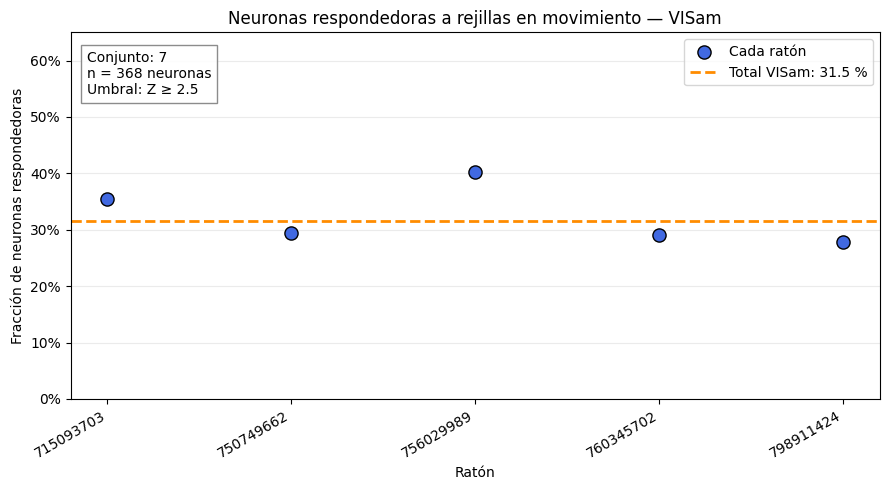

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

NUMERO_CONJUNTO = "7"  # Cambiar por el número asignado

ratones = np.unique(d["u_raton"])
fracciones_ratones = []
totales_ratones = []

for raton in ratones:
    neuronas_raton = d["u_raton"] == raton

    total = np.sum(neuronas_raton)
    fraccion = np.mean(respondedoras[neuronas_raton])

    totales_ratones.append(total)
    fracciones_ratones.append(fraccion)

fracciones_ratones = np.array(fracciones_ratones)

# Crear la gráfica
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    np.arange(len(ratones)),
    fracciones_ratones,
    s=90,
    color="royalblue",
    edgecolor="black",
    zorder=3,
    label="Cada ratón"
)

# Fracción calculada con todas las neuronas
ax.axhline(
    fraccion_respondedora,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Total VISam: {fraccion_respondedora * 100:.1f} %"
)

ax.set_xticks(np.arange(len(ratones)))
ax.set_xticklabels(ratones, rotation=30, ha="right")

ax.set_xlabel("Ratón")
ax.set_ylabel("Fracción de neuronas respondedoras")
ax.set_title("Neuronas respondedoras a rejillas en movimiento — VISam")

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, max(0.65, fracciones_ratones.max() + 0.08))
ax.grid(axis="y", alpha=0.25)
ax.legend()

# Información dentro de la figura
ax.text(
    0.02,
    0.95,
    f"Conjunto: {NUMERO_CONJUNTO}\n"
    f"n = {n_neuronas} neuronas\n"
    f"Umbral: Z ≥ 2.5",
    transform=ax.transAxes,
    va="top",
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.tight_layout()
plt.show()

---
## Para cerrar

Anoten su número: **la fracción de neuronas de su área que responden a las rejillas en movimiento**.

31.5% de las neuronas respondieron a las rejillas en movimiento. 116 de 368 neuronas con un z > 2.5

Ese número va al póster y es el que comparamos entre las once parejas el viernes 25. Puestos en
orden de área, los once juntos reconstruyen la jerarquía visual del ratón.

Guarden este notebook en su repositorio de GitHub. Es la primera pieza del pipeline del proyecto.

# Análisis del proyecto final: frecuencia temporal de 1 Hz vs 15 Hz

Para el área VISam se comparó la respuesta neuronal ante rejillas en
movimiento con frecuencias temporales de 1 Hz y 15 Hz. La predicción
inicial fue una respuesta mayor ante 15 Hz.

In [9]:

# Separar las rejillas por frecuencia temporal


# Frecuencias temporales de las rejillas válidas
frecuencias_validas = frec_temporal[rejillas_validas]

# Índices, dentro de tasa_evocada, de las rejillas reales
columnas_rejillas_validas = np.where(rejillas_validas)[0]

# Columnas correspondientes a 1 Hz y 15 Hz
columnas_1hz = columnas_rejillas_validas[
    frecuencias_validas == 1
]

columnas_15hz = columnas_rejillas_validas[
    frecuencias_validas == 15
]

# Tasas por neurona y ensayo
tasas_1hz = tasa_evocada[:, columnas_1hz]
tasas_15hz = tasa_evocada[:, columnas_15hz]

# Promedio de cada neurona, usando solo los ensayos de su ratón
media_1hz = np.nanmean(tasas_1hz, axis=1)
media_15hz = np.nanmean(tasas_15hz, axis=1)

# Z-score frente a la actividad basal propia de cada neurona
z_1hz = np.divide(
    media_1hz - media_basal,
    desviacion_basal,
    out=np.full(n_neuronas, np.nan),
    where=desviacion_basal > 0
)

z_15hz = np.divide(
    media_15hz - media_basal,
    desviacion_basal,
    out=np.full(n_neuronas, np.nan),
    where=desviacion_basal > 0
)

print("Ensayos totales de 1 Hz:", len(columnas_1hz))
print("Ensayos totales de 15 Hz:", len(columnas_15hz))

print(
    "Ensayos válidos de 1 Hz por neurona:",
    np.unique(np.sum(~np.isnan(tasas_1hz), axis=1))
)

print(
    "Ensayos válidos de 15 Hz por neurona:",
    np.unique(np.sum(~np.isnan(tasas_15hz), axis=1))
)

print(f"Mediana de la tasa a 1 Hz: {np.nanmedian(media_1hz):.2f} Hz")
print(f"Mediana de la tasa a 15 Hz: {np.nanmedian(media_15hz):.2f} Hz")

print(f"Mediana del Z-score a 1 Hz: {np.nanmedian(z_1hz):.2f}")
print(f"Mediana del Z-score a 15 Hz: {np.nanmedian(z_15hz):.2f}")

Ensayos totales de 1 Hz: 380
Ensayos totales de 15 Hz: 385
Ensayos válidos de 1 Hz por neurona: [76]
Ensayos válidos de 15 Hz por neurona: [77]
Mediana de la tasa a 1 Hz: 3.76 Hz
Mediana de la tasa a 15 Hz: 2.68 Hz
Mediana del Z-score a 1 Hz: 0.09
Mediana del Z-score a 15 Hz: -0.06


#Respuesta a todas las frecuencias temporales

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

frecuencias = np.array([1, 2, 4, 8, 15], dtype=float)

# Filas = neuronas
# Columnas = frecuencias temporales
media_por_frecuencia = np.full(
    (n_neuronas, len(frecuencias)),
    np.nan
)

z_por_frecuencia = np.full_like(
    media_por_frecuencia,
    np.nan
)

for j, frecuencia in enumerate(frecuencias):

    # Columnas dentro de tasa_evocada que corresponden a esta frecuencia
    columnas_frecuencia = columnas_rejillas_validas[
        frecuencias_validas == frecuencia
    ]

    tasas_frecuencia = tasa_evocada[:, columnas_frecuencia]

    # Promedio de cada neurona sobre orientaciones y repeticiones
    media_por_frecuencia[:, j] = np.nanmean(
        tasas_frecuencia,
        axis=1
    )

    # Z-score contra la actividad basal de la misma neurona
    z_por_frecuencia[:, j] = np.divide(
        media_por_frecuencia[:, j] - media_basal,
        desviacion_basal,
        out=np.full(n_neuronas, np.nan),
        where=desviacion_basal > 0
    )

print("Forma de la matriz de tasas:", media_por_frecuencia.shape)
print("Forma de la matriz de Z-scores:", z_por_frecuencia.shape)

for j, frecuencia in enumerate(frecuencias):
    print(
        f"{frecuencia:g} Hz: "
        f"tasa mediana = {np.nanmedian(media_por_frecuencia[:, j]):.2f} Hz, "
        f"Z mediano = {np.nanmedian(z_por_frecuencia[:, j]):.2f}"
    )

Forma de la matriz de tasas: (368, 5)
Forma de la matriz de Z-scores: (368, 5)
1 Hz: tasa mediana = 3.76 Hz, Z mediano = 0.09
2 Hz: tasa mediana = 3.62 Hz, Z mediano = 0.07
4 Hz: tasa mediana = 3.05 Hz, Z mediano = 0.01
8 Hz: tasa mediana = 2.67 Hz, Z mediano = -0.02
15 Hz: tasa mediana = 2.68 Hz, Z mediano = -0.06


# mapa de calor
Estas graficas no corresponden a las del poster, son para visualizar los datos que estamos sacando

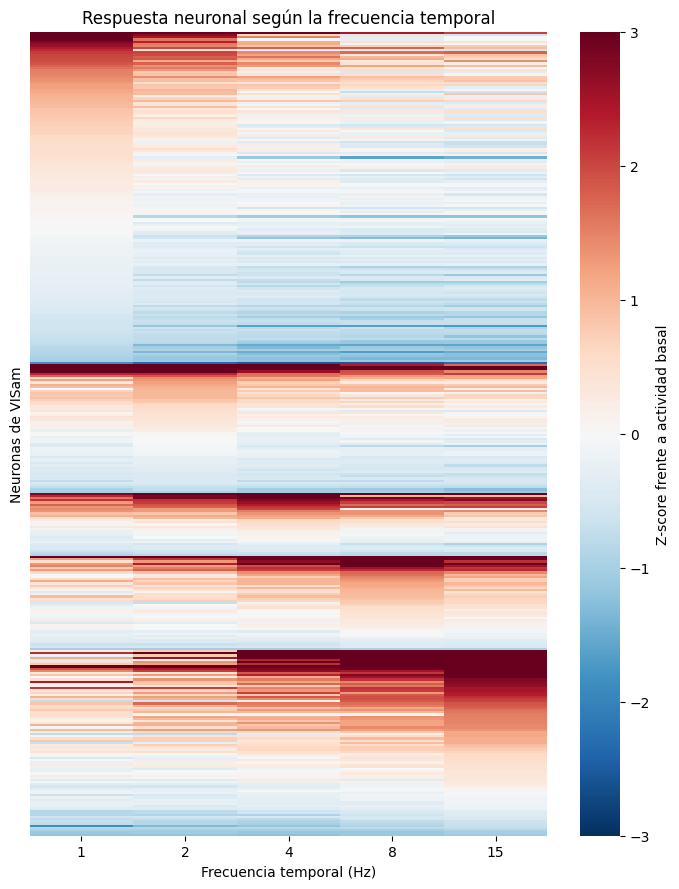

In [11]:
# Frecuencia con mayor tasa promedio para cada neurona
indice_frecuencia_preferida = np.nanargmax(
    media_por_frecuencia,
    axis=1
)

frecuencia_preferida = frecuencias[
    indice_frecuencia_preferida
]

# Ordenar primero por frecuencia preferida y luego por respuesta máxima
respuesta_maxima = np.nanmax(z_por_frecuencia, axis=1)

orden_neuronas = np.lexsort((
    -respuesta_maxima,
    indice_frecuencia_preferida
))

plt.figure(figsize=(7, 9))

sns.heatmap(
    z_por_frecuencia[orden_neuronas],
    cmap="RdBu_r",
    center=0,
    vmin=-3,
    vmax=3,
    xticklabels=[f"{f:g}" for f in frecuencias],
    yticklabels=False,
    cbar_kws={"label": "Z-score frente a actividad basal"}
)

plt.xlabel("Frecuencia temporal (Hz)")
plt.ylabel("Neuronas de VISam")
plt.title("Respuesta neuronal según la frecuencia temporal")
plt.tight_layout()
plt.show()

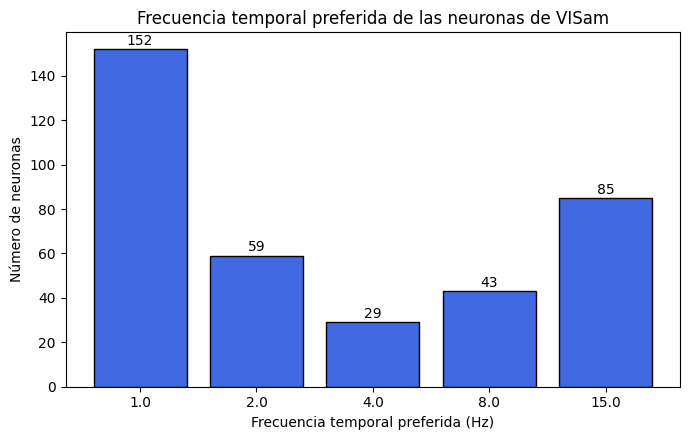

Frecuencia preferida por neurona:
1 Hz: 152 neuronas
2 Hz: 59 neuronas
4 Hz: 29 neuronas
8 Hz: 43 neuronas
15 Hz: 85 neuronas


In [12]:
valores, cantidades = np.unique(
    frecuencia_preferida,
    return_counts=True
)

plt.figure(figsize=(7, 4.5))

plt.bar(
    valores.astype(str),
    cantidades,
    color="royalblue",
    edgecolor="black"
)

plt.xlabel("Frecuencia temporal preferida (Hz)")
plt.ylabel("Número de neuronas")
plt.title("Frecuencia temporal preferida de las neuronas de VISam")

for i, cantidad in enumerate(cantidades):
    plt.text(
        i,
        cantidad + 2,
        str(cantidad),
        ha="center"
    )

plt.tight_layout()
plt.show()

print("Frecuencia preferida por neurona:")
for valor, cantidad in zip(valores, cantidades):
    print(f"{valor:g} Hz: {cantidad} neuronas")

La frecuencia temporal preferida fue 1 Hz para 152 de las 368 neuronas (41,3 %), mientras que 85 neuronas (23,1 %) presentaron su respuesta máxima a 15 Hz. Por lo tanto, la distribución de preferencias no apoyó la predicción inicial de un predominio de 15 Hz en VISam.

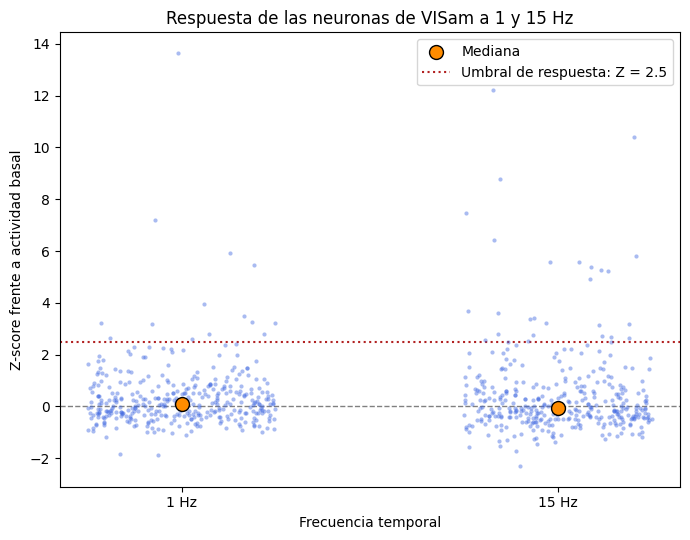

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

datos_enjambre = pd.DataFrame({
    "Z-score": np.concatenate([z_1hz, z_15hz]),
    "Frecuencia": (
        ["1 Hz"] * n_neuronas +
        ["15 Hz"] * n_neuronas
    )
})

plt.figure(figsize=(7, 5.5))

sns.stripplot(
    data=datos_enjambre,
    x="Frecuencia",
    y="Z-score",
    order=["1 Hz", "15 Hz"],
    jitter=0.25,
    size=3,
    alpha=0.45,
    color="royalblue"
)

# Medianas de cada condición
medianas_z = [
    np.nanmedian(z_1hz),
    np.nanmedian(z_15hz)
]

plt.scatter(
    [0, 1],
    medianas_z,
    color="darkorange",
    edgecolor="black",
    s=100,
    zorder=5,
    label="Mediana"
)

plt.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.axhline(
    2.5,
    color="firebrick",
    linestyle=":",
    linewidth=1.5,
    label="Umbral de respuesta: Z = 2.5"
)

plt.xlabel("Frecuencia temporal")
plt.ylabel("Z-score frente a actividad basal")
plt.title("Respuesta de las neuronas de VISam a 1 y 15 Hz")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
UMBRAL_Z = 2.5

respondedoras_1hz = z_1hz >= UMBRAL_Z
respondedoras_15hz = z_15hz >= UMBRAL_Z

n_resp_1hz = np.sum(respondedoras_1hz)
n_resp_15hz = np.sum(respondedoras_15hz)

fraccion_1hz = np.mean(respondedoras_1hz)
fraccion_15hz = np.mean(respondedoras_15hz)

print(
    f"1 Hz: {n_resp_1hz} de {n_neuronas} neuronas "
    f"({fraccion_1hz * 100:.1f} %)"
)

print(
    f"15 Hz: {n_resp_15hz} de {n_neuronas} neuronas "
    f"({fraccion_15hz * 100:.1f} %)"
)

1 Hz: 14 de 368 neuronas (3.8 %)
15 Hz: 26 de 368 neuronas (7.1 %)


In [15]:
fracciones_1hz_raton = []
fracciones_15hz_raton = []

print("Fracciones respondedoras por ratón:\n")

for raton in ratones:
    mascara = d["u_raton"] == raton

    total = np.sum(mascara)
    f1 = np.mean(respondedoras_1hz[mascara])
    f15 = np.mean(respondedoras_15hz[mascara])

    fracciones_1hz_raton.append(f1)
    fracciones_15hz_raton.append(f15)

    print(
        f"Ratón {raton}: n = {total}, "
        f"1 Hz = {f1 * 100:.1f} %, "
        f"15 Hz = {f15 * 100:.1f} %"
    )

fracciones_1hz_raton = np.array(fracciones_1hz_raton)
fracciones_15hz_raton = np.array(fracciones_15hz_raton)

print(
    "\nPromedio entre ratones:"
    f"\n1 Hz = {np.mean(fracciones_1hz_raton) * 100:.1f} %"
    f"\n15 Hz = {np.mean(fracciones_15hz_raton) * 100:.1f} %"
)

Fracciones respondedoras por ratón:

Ratón 715093703: n = 31, 1 Hz = 3.2 %, 15 Hz = 9.7 %
Ratón 750749662: n = 68, 1 Hz = 4.4 %, 15 Hz = 8.8 %
Ratón 756029989: n = 77, 1 Hz = 5.2 %, 15 Hz = 10.4 %
Ratón 760345702: n = 55, 1 Hz = 0.0 %, 15 Hz = 3.6 %
Ratón 798911424: n = 137, 1 Hz = 4.4 %, 15 Hz = 5.1 %

Promedio entre ratones:
1 Hz = 3.4 %
15 Hz = 7.5 %


Aunque la tasa mediana fue mayor a 1 Hz, la proporción de neuronas con una respuesta fuerte respecto a su actividad basal fue mayor a 15 Hz. Esta diferencia apareció en los cinco ratones.

#Bootstrap jerárquico de tres niveles

In [16]:

# Bootstrap jerárquico de tres niveles


rng = np.random.default_rng(2026)

N_BOOT_ENSAYOS = 1000
N_BOOT_JERARQUICO = 10000
UMBRAL_Z = 2.5

# Quitar los NaN que representan ensayos de otros ratones.
# Todas las neuronas tienen 76 ensayos de 1 Hz, 77 de 15 Hz
# y 150 ensayos espontáneos.
t1_limpia = np.stack([
    fila[~np.isnan(fila)] for fila in tasas_1hz
])

t15_limpia = np.stack([
    fila[~np.isnan(fila)] for fila in tasas_15hz
])

basal_limpia = np.stack([
    fila[~np.isnan(fila)] for fila in tasa_basal
])

print("Matrices limpias:")
print("1 Hz:", t1_limpia.shape)
print("15 Hz:", t15_limpia.shape)
print("Basal:", basal_limpia.shape)

Matrices limpias:
1 Hz: (368, 76)
15 Hz: (368, 77)
Basal: (368, 150)


In [17]:
# Guarda, para cada repetición y neurona, si respondió a 1 y 15 Hz
boot_respuesta = np.zeros(
    (N_BOOT_ENSAYOS, n_neuronas, 2),
    dtype=bool
)

for b in range(N_BOOT_ENSAYOS):

    # Remuestreo independiente de ensayos dentro de cada neurona
    idx_basal = rng.integers(
        0,
        basal_limpia.shape[1],
        size=basal_limpia.shape
    )

    idx_1hz = rng.integers(
        0,
        t1_limpia.shape[1],
        size=t1_limpia.shape
    )

    idx_15hz = rng.integers(
        0,
        t15_limpia.shape[1],
        size=t15_limpia.shape
    )

    basal_b = np.take_along_axis(
        basal_limpia,
        idx_basal,
        axis=1
    )

    t1_b = np.take_along_axis(
        t1_limpia,
        idx_1hz,
        axis=1
    )

    t15_b = np.take_along_axis(
        t15_limpia,
        idx_15hz,
        axis=1
    )

    media_basal_b = np.mean(basal_b, axis=1)
    sd_basal_b = np.std(basal_b, axis=1, ddof=1)

    z1_b = np.divide(
        np.mean(t1_b, axis=1) - media_basal_b,
        sd_basal_b,
        out=np.full(n_neuronas, np.nan),
        where=sd_basal_b > 0
    )

    z15_b = np.divide(
        np.mean(t15_b, axis=1) - media_basal_b,
        sd_basal_b,
        out=np.full(n_neuronas, np.nan),
        where=sd_basal_b > 0
    )

    boot_respuesta[b, :, 0] = z1_b >= UMBRAL_Z
    boot_respuesta[b, :, 1] = z15_b >= UMBRAL_Z

print("Banco de remuestreos creado:", boot_respuesta.shape)

Banco de remuestreos creado: (1000, 368, 2)


In [18]:
ratones = np.unique(d["u_raton"])

indices_por_raton = {
    raton: np.where(d["u_raton"] == raton)[0]
    for raton in ratones
}

boot_fraccion_1hz = np.empty(N_BOOT_JERARQUICO)
boot_fraccion_15hz = np.empty(N_BOOT_JERARQUICO)
boot_diferencia = np.empty(N_BOOT_JERARQUICO)

for b in range(N_BOOT_JERARQUICO):

    # Nivel 1: cinco ratones con reemplazo
    ratones_b = rng.choice(
        ratones,
        size=len(ratones),
        replace=True
    )

    respuestas_b = []

    for raton in ratones_b:

        neuronas_originales = indices_por_raton[raton]
        n_raton = len(neuronas_originales)

        # Nivel 2: neuronas del ratón con reemplazo
        neuronas_b = rng.choice(
            neuronas_originales,
            size=n_raton,
            replace=True
        )

        # Nivel 3: tomar un remuestreo de ensayos para cada neurona
        replicas_ensayos = rng.integers(
            0,
            N_BOOT_ENSAYOS,
            size=n_raton
        )

        respuesta_raton = boot_respuesta[
            replicas_ensayos,
            neuronas_b,
            :
        ]

        respuestas_b.append(respuesta_raton)

    respuestas_b = np.vstack(respuestas_b)

    f1_b = np.mean(respuestas_b[:, 0])
    f15_b = np.mean(respuestas_b[:, 1])

    boot_fraccion_1hz[b] = f1_b
    boot_fraccion_15hz[b] = f15_b
    boot_diferencia[b] = f15_b - f1_b

In [19]:
#intervalo de confianza
ic_1hz = np.percentile(
    boot_fraccion_1hz,
    [2.5, 97.5]
)

ic_15hz = np.percentile(
    boot_fraccion_15hz,
    [2.5, 97.5]
)

ic_diferencia = np.percentile(
    boot_diferencia,
    [2.5, 97.5]
)

diferencia_observada = fraccion_15hz - fraccion_1hz

print(
    f"1 Hz: {fraccion_1hz * 100:.1f} % "
    f"[IC 95 %: {ic_1hz[0] * 100:.1f}, "
    f"{ic_1hz[1] * 100:.1f}]"
)

print(
    f"15 Hz: {fraccion_15hz * 100:.1f} % "
    f"[IC 95 %: {ic_15hz[0] * 100:.1f}, "
    f"{ic_15hz[1] * 100:.1f}]"
)

print(
    f"Diferencia 15 Hz − 1 Hz: "
    f"{diferencia_observada * 100:.1f} puntos porcentuales "
    f"[IC 95 %: {ic_diferencia[0] * 100:.1f}, "
    f"{ic_diferencia[1] * 100:.1f}]"
)

1 Hz: 3.8 % [IC 95 %: 1.5, 7.1]
15 Hz: 7.1 % [IC 95 %: 4.3, 11.3]
Diferencia 15 Hz − 1 Hz: 3.3 puntos porcentuales [IC 95 %: -0.2, 6.9]


La fracción de neuronas respondedoras fue mayor a 15 Hz (7,1 %, IC 95 %: 4,3–11,3 %) que a 1 Hz (3,8 %, IC 95 %: 1,5–7,1 %). La diferencia fue de 3,3 puntos porcentuales, aunque su intervalo de confianza incluyó cero (IC 95 %: −0,2–6,9).

#Prueba de permutación y \(d\) de Cohen

In [20]:
from itertools import product

# Diferencia pareada de cada ratón
diferencias_raton = (
    fracciones_15hz_raton -
    fracciones_1hz_raton
)

diferencia_media_raton = np.mean(diferencias_raton)

# Todas las 2^5 permutaciones posibles de signo
signos = np.array(
    list(product([-1, 1], repeat=len(ratones)))
)

distribucion_nula = np.mean(
    signos * diferencias_raton,
    axis=1
)

# Prueba bilateral exacta
p_permutacion = np.mean(
    np.abs(distribucion_nula) >=
    np.abs(diferencia_media_raton)
)

# Cohen dz para datos pareados, con el ratón como unidad
sd_diferencias = np.std(
    diferencias_raton,
    ddof=1
)

cohen_dz = (
    diferencia_media_raton /
    sd_diferencias
)

print("Diferencias 15 Hz − 1 Hz por ratón:")
for raton, diferencia in zip(ratones, diferencias_raton):
    print(
        f"Ratón {raton}: "
        f"{diferencia * 100:.1f} puntos porcentuales"
    )

print(
    f"\nDiferencia media entre ratones: "
    f"{diferencia_media_raton * 100:.1f} puntos porcentuales"
)

print(f"p de permutación bilateral exacta: {p_permutacion:.4f}")
print(f"Cohen dz pareado: {cohen_dz:.2f}")

Diferencias 15 Hz − 1 Hz por ratón:
Ratón 715093703: 6.5 puntos porcentuales
Ratón 750749662: 4.4 puntos porcentuales
Ratón 756029989: 5.2 puntos porcentuales
Ratón 760345702: 3.6 puntos porcentuales
Ratón 798911424: 0.7 puntos porcentuales

Diferencia media entre ratones: 4.1 puntos porcentuales
p de permutación bilateral exacta: 0.0625
Cohen dz pareado: 1.90


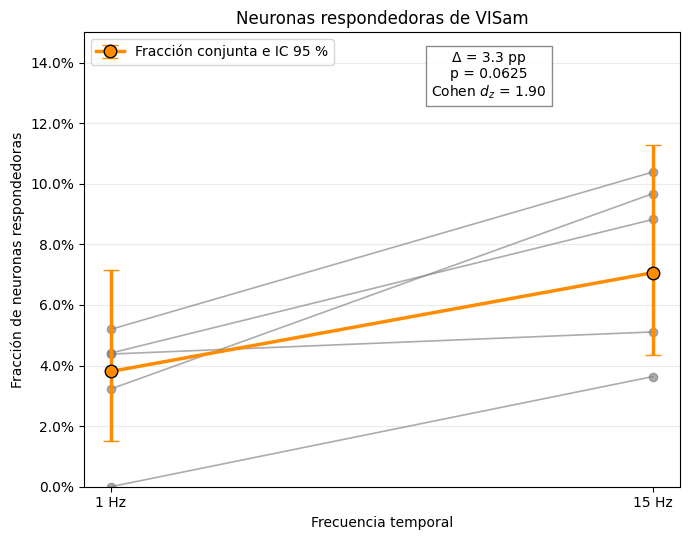

In [21]:
fig, ax = plt.subplots(figsize=(7, 5.5))

x = np.array([0, 1])

# Cada línea gris representa un ratón
for i, raton in enumerate(ratones):
    ax.plot(
        x,
        [
            fracciones_1hz_raton[i],
            fracciones_15hz_raton[i]
        ],
        marker="o",
        color="gray",
        alpha=0.65,
        linewidth=1.2
    )

# Fracciones conjuntas
fracciones_globales = np.array([
    fraccion_1hz,
    fraccion_15hz
])

# IC asimétricos del bootstrap
errores_inferiores = np.array([
    fraccion_1hz - ic_1hz[0],
    fraccion_15hz - ic_15hz[0]
])

errores_superiores = np.array([
    ic_1hz[1] - fraccion_1hz,
    ic_15hz[1] - fraccion_15hz
])

ax.errorbar(
    x,
    fracciones_globales,
    yerr=[errores_inferiores, errores_superiores],
    fmt="o-",
    color="darkorange",
    markeredgecolor="black",
    markersize=9,
    linewidth=2.5,
    capsize=6,
    label="Fracción conjunta e IC 95 %"
)

ax.set_xticks(x)
ax.set_xticklabels(["1 Hz", "15 Hz"])
ax.set_ylabel("Fracción de neuronas respondedoras")
ax.set_xlabel("Frecuencia temporal")
ax.set_title("Neuronas respondedoras de VISam")

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, max(0.15, ic_15hz[1] + 0.03))

ax.text(
    0.68,
    0.96,
    f"Δ = {diferencia_observada * 100:.1f} pp\n"
    f"p = {p_permutacion:.4f}\n"
    f"Cohen $d_z$ = {cohen_dz:.2f}",
    transform=ax.transAxes,
    ha="center",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
# Esta línea debe ir justo antes de plt.show() en cada gráfica

plt.savefig(
    "panel_2E.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

Los cinco ratones presentaron una mayor fracción de neuronas respondedoras a 15 Hz. Aunque el tamaño del efecto entre animales fue grande (\(d_z=1,90\)), la diferencia no fue concluyente con una prueba bilateral exacta (\(p=0,0625\); diferencia: 3,3 pp, IC 95 %: −0,2–6,9).
Que el efecto sea grande pero el valor \(p\) no sea menor a 0,05 no es un error. Solo hay cinco ratones, por lo que la prueba tiene poca resolución.

In [22]:
# Neuronas que responden a 15 Hz
candidatas_15hz = np.where(z_15hz >= 2.5)[0]

# Escoger una respuesta fuerte pero no el valor más extremo
percentil_75 = np.nanpercentile(
    z_15hz[candidatas_15hz],
    75
)

neurona_ejemplo = candidatas_15hz[
    np.argmin(
        np.abs(
            z_15hz[candidatas_15hz] -
            percentil_75
        )
    )
]

print("Índice de la neurona ejemplo:", neurona_ejemplo)
print("ID de la neurona:", d["u_id"][neurona_ejemplo])
print("Ratón:", d["u_raton"][neurona_ejemplo])
print(f"Z-score a 1 Hz: {z_1hz[neurona_ejemplo]:.2f}")
print(f"Z-score a 15 Hz: {z_15hz[neurona_ejemplo]:.2f}")
print(
    "Forma de la onda:",
    d["u_onda"][neurona_ejemplo].shape
)

Índice de la neurona ejemplo: 64
ID de la neurona: 951092567
Ratón: 798911424
Z-score a 1 Hz: 5.46
Z-score a 15 Hz: 5.57
Forma de la onda: (7, 82)


Elegimos la neurona 64, la cual estaba mostrando mas una respuesta con fuerza a ambas frecuencias, ademas su z score es ligeramente mayor a 15 Hz

#**FIGURA 1**
#**PANEL B**
ESQUEMA DEL ESTIMULO REJILLAS

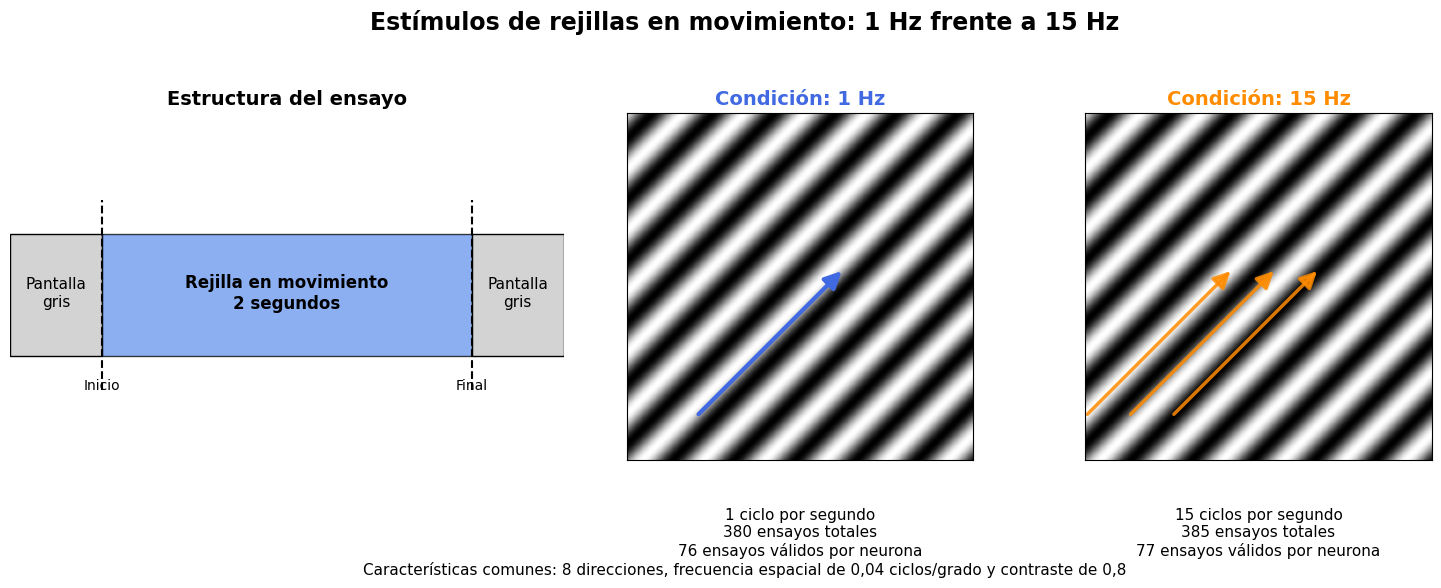

Panel guardado como: panel_1B.png


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch


# FIGURA 1B: esquema de las condiciones asignadas


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    gridspec_kw={
        "width_ratios": [1.25, 1, 1]
    }
)


# Parte izquierda: secuencia temporal del ensayo


ax = axes[0]

ax.set_xlim(-0.5, 2.5)
ax.set_ylim(0, 1)
ax.axis("off")

# Periodo previo
ax.add_patch(
    Rectangle(
        (-0.5, 0.30),
        0.5,
        0.35,
        facecolor="lightgray",
        edgecolor="black"
    )
)

# Presentación de la rejilla
ax.add_patch(
    Rectangle(
        (0, 0.30),
        2,
        0.35,
        facecolor="cornflowerblue",
        edgecolor="black",
        alpha=0.75
    )
)

# Periodo posterior
ax.add_patch(
    Rectangle(
        (2, 0.30),
        0.5,
        0.35,
        facecolor="lightgray",
        edgecolor="black"
    )
)

ax.text(
    -0.25,
    0.48,
    "Pantalla\ngris",
    ha="center",
    va="center",
    fontsize=11
)

ax.text(
    1,
    0.48,
    "Rejilla en movimiento\n2 segundos",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

ax.text(
    2.25,
    0.48,
    "Pantalla\ngris",
    ha="center",
    va="center",
    fontsize=11
)

ax.axvline(
    0,
    ymin=0.20,
    ymax=0.75,
    color="black",
    linestyle="--"
)

ax.axvline(
    2,
    ymin=0.20,
    ymax=0.75,
    color="black",
    linestyle="--"
)

ax.text(
    0,
    0.20,
    "Inicio",
    ha="center",
    fontsize=10
)

ax.text(
    2,
    0.20,
    "Final",
    ha="center",
    fontsize=10
)

ax.set_title(
    "Estructura del ensayo",
    fontsize=14,
    fontweight="bold"
)


# Crear una imagen de una rejilla


x = np.linspace(-1, 1, 300)
y = np.linspace(-1, 1, 300)

X, Y = np.meshgrid(x, y)

angulo = np.deg2rad(45)

rejilla = np.sin(
    2 * np.pi * 4
    * (
        X * np.cos(angulo)
        + Y * np.sin(angulo)
    )
)


# Parte central: condición de 1 Hz


ax = axes[1]

ax.imshow(
    rejilla,
    cmap="gray",
    extent=(-1, 1, -1, 1),
    vmin=-1,
    vmax=1
)

flecha_1 = FancyArrowPatch(
    (-0.60, -0.75),
    (0.25, 0.10),
    arrowstyle="-|>",
    mutation_scale=25,
    linewidth=3,
    color="royalblue"
)

ax.add_patch(flecha_1)

ax.set_title(
    "Condición: 1 Hz",
    fontsize=14,
    fontweight="bold",
    color="royalblue"
)

ax.text(
    0,
    -1.28,
    "1 ciclo por segundo\n"
    "380 ensayos totales\n"
    "76 ensayos válidos por neurona",
    ha="center",
    va="top",
    fontsize=11
)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xticks([])
ax.set_yticks([])


# Parte derecha: condición de 15 Hz


ax = axes[2]

ax.imshow(
    rejilla,
    cmap="gray",
    extent=(-1, 1, -1, 1),
    vmin=-1,
    vmax=1
)

# Varias flechas representan un movimiento más rápido
for desplazamiento in [-0.25, 0, 0.25]:

    flecha_15 = FancyArrowPatch(
        (
            -0.75 + desplazamiento,
            -0.75
        ),
        (
            0.10 + desplazamiento,
            0.10
        ),
        arrowstyle="-|>",
        mutation_scale=25,
        linewidth=2.5,
        color="darkorange",
        alpha=0.85
    )

    ax.add_patch(flecha_15)

ax.set_title(
    "Condición: 15 Hz",
    fontsize=14,
    fontweight="bold",
    color="darkorange"
)

ax.text(
    0,
    -1.28,
    "15 ciclos por segundo\n"
    "385 ensayos totales\n"
    "77 ensayos válidos por neurona",
    ha="center",
    va="top",
    fontsize=11
)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xticks([])
ax.set_yticks([])


# Título y características comunes


fig.suptitle(
    "Estímulos de rejillas en movimiento: 1 Hz frente a 15 Hz",
    fontsize=17,
    fontweight="bold",
    y=1.05
)

fig.text(
    0.5,
    -0.08,
    "Características comunes: 8 direcciones, frecuencia espacial de "
    "0,04 ciclos/grado y contraste de 0,8",
    ha="center",
    fontsize=11
)

plt.tight_layout()

# Guardar para unirlo después con 1A, 1C y 1D
plt.savefig(
    "panel_1B.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Panel guardado como: panel_1B.png")

#**FIGURA 1**
#**PANEL C**
FORMA DE ONDA DE NEURONA EJEMPLO

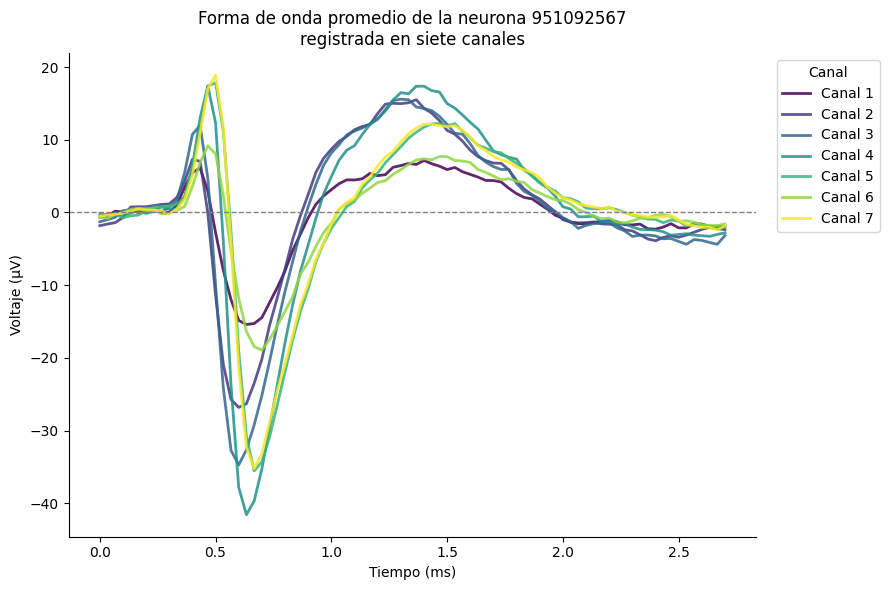

In [41]:

# FIGURA 1C · Forma de onda de la neurona ejemplo

import numpy as np
import matplotlib.pyplot as plt

# Neurona ejemplo
indice_neurona = 64
id_neurona = d["u_id"][indice_neurona]

# Siete canales × 82 muestras
onda = d["u_onda"][indice_neurona].astype(float)

# Tiempo en milisegundos
frecuencia_muestreo = 30000

tiempo_ms = (
    np.arange(onda.shape[1])
    / frecuencia_muestreo
    * 1000
)

# Ajustar cada canal a su línea basal
onda_centrada = (
    onda
    - np.mean(onda[:, :10], axis=1)[:, None]
)

# Colores distintos para cada canal
colores = plt.cm.viridis(
    np.linspace(0, 1, onda.shape[0])
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

for canal in range(onda.shape[0]):

    ax.plot(
        tiempo_ms,
        onda_centrada[canal],
        color=colores[canal],
        linewidth=2,
        alpha=0.85,
        label=f"Canal {canal + 1}"
    )

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

ax.set_xlabel(
    "Tiempo (ms)"
)

ax.set_ylabel(
    "Voltaje (µV)"
)

ax.set_title(
    f"Forma de onda promedio de la neurona {id_neurona}\n"
    "registrada en siete canales"
)

ax.legend(
    title="Canal",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "panel_1C_superpuesto.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

#**FIGURA 1**
# **PANEL D**
RASTER Y PSTH DE NEURONA EJEMPLO
NEURONA CON INDICE 64

In [26]:

# FIGURA 1D · Raster y PSTH de la neurona ejemplo


# Convertir las columnas de tasa_evocada en índices globales
# de la tabla de ensayos
ensayos_15hz_global = idx_rejillas[columnas_15hz]

# Conservar solo los ensayos del ratón de la neurona ejemplo
raton_ejemplo = d["u_raton"][neurona_ejemplo]

ensayos_ejemplo = ensayos_15hz_global[
    d["e_raton"][ensayos_15hz_global] == raton_ejemplo
]

# Extraer primero todas las espigas de la neurona
mascara_neurona = d["s_unidad"] == neurona_ejemplo

ensayos_spikes_neurona = d["s_ensayo"][mascara_neurona]
tiempos_spikes_neurona = d["s_t"][mascara_neurona]

print("Número de ensayos de 15 Hz:", len(ensayos_ejemplo))
print(
    "Rango temporal disponible:",
    np.min(tiempos_spikes_neurona),
    "a",
    np.max(tiempos_spikes_neurona),
    "s"
)

Número de ensayos de 15 Hz: 77
Rango temporal disponible: -0.86095864 a 30.877474 s


In [27]:
# Ventana alrededor del inicio del estímulo
inicio = -0.5
final = 2.5
ancho_bin = 0.05  # 50 ms

bordes = np.arange(
    inicio,
    final + ancho_bin,
    ancho_bin
)

centros = (bordes[:-1] + bordes[1:]) / 2

# Una fila por ensayo y una columna por intervalo temporal
conteos_por_ensayo = np.zeros(
    (len(ensayos_ejemplo), len(centros))
)

espigas_por_ensayo = []

for i, ensayo in enumerate(ensayos_ejemplo):

    tiempos = tiempos_spikes_neurona[
        ensayos_spikes_neurona == ensayo
    ]

    tiempos = tiempos[
        (tiempos >= inicio) &
        (tiempos < final)
    ]

    espigas_por_ensayo.append(tiempos)

    conteos_por_ensayo[i], _ = np.histogram(
        tiempos,
        bins=bordes
    )

# Convertir conteos a tasa en Hz
tasas_por_ensayo = (
    conteos_por_ensayo / ancho_bin
)

psth_promedio = np.mean(
    tasas_por_ensayo,
    axis=0
)

psth_sem = np.std(
    tasas_por_ensayo,
    axis=0,
    ddof=1
) / np.sqrt(len(ensayos_ejemplo))

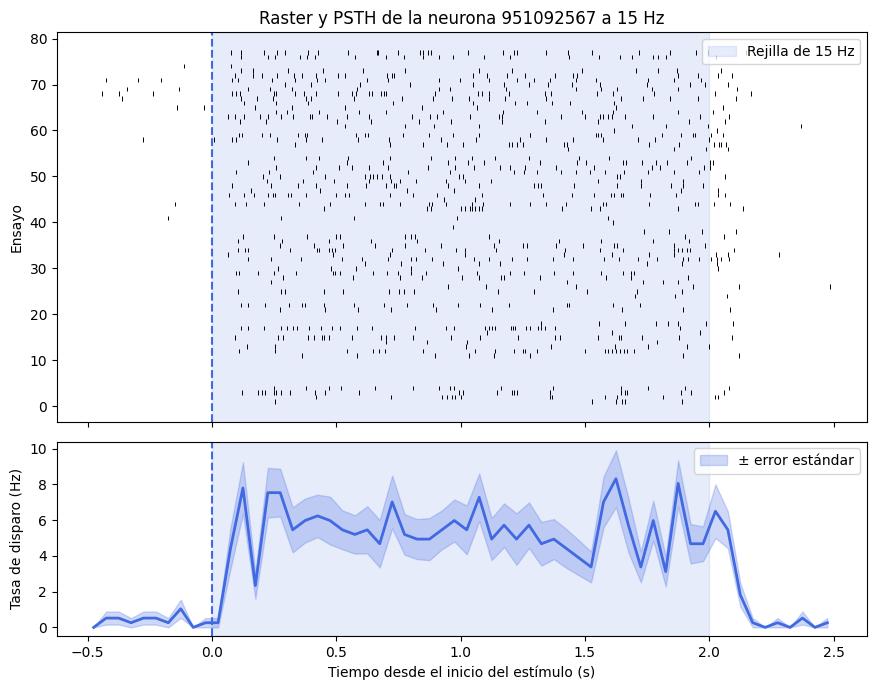

In [28]:
fig, (ax_raster, ax_psth) = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# Raster
for i, tiempos in enumerate(espigas_por_ensayo):
    ax_raster.vlines(
        tiempos,
        i + 0.5,
        i + 1.5,
        color="black",
        linewidth=0.7
    )

ax_raster.axvspan(
    0,
    2,
    color="royalblue",
    alpha=0.12,
    label="Rejilla de 15 Hz"
)

ax_raster.axvline(
    0,
    color="royalblue",
    linestyle="--"
)

ax_raster.set_ylabel("Ensayo")
ax_raster.set_title(
    f"Raster y PSTH de la neurona {d['u_id'][neurona_ejemplo]} "
    f"a 15 Hz"
)
ax_raster.legend(loc="upper right")

# PSTH
ax_psth.plot(
    centros,
    psth_promedio,
    color="royalblue",
    linewidth=2
)

ax_psth.fill_between(
    centros,
    psth_promedio - psth_sem,
    psth_promedio + psth_sem,
    color="royalblue",
    alpha=0.25,
    label="± error estándar"
)

ax_psth.axvspan(
    0,
    2,
    color="royalblue",
    alpha=0.12
)

ax_psth.axvline(
    0,
    color="royalblue",
    linestyle="--"
)

ax_psth.set_xlabel("Tiempo desde el inicio del estímulo (s)")
ax_psth.set_ylabel("Tasa de disparo (Hz)")
ax_psth.legend(loc="upper right")

plt.tight_layout()
# Esta línea debe ir justo antes de plt.show() en cada gráfica

plt.savefig(
    "panel_1D.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

In [29]:

# Función para calcular el PSTH de una población


def psth_poblacional(
    ensayos_globales,
    inicio=-0.5,
    final=2.5,
    ancho_bin=0.05
):
    bordes = np.arange(
        inicio,
        final + ancho_bin,
        ancho_bin
    )

    centros = (bordes[:-1] + bordes[1:]) / 2
    n_bins = len(centros)

    # Indica qué ensayos pertenecen a la condición
    ensayo_elegible = np.zeros(
        len(d["e_clase"]),
        dtype=bool
    )

    ensayo_elegible[ensayos_globales] = True

    # Número de ensayos de la condición para cada ratón
    n_ensayos_por_raton = {
        raton: np.sum(
            d["e_raton"][ensayos_globales] == raton
        )
        for raton in np.unique(d["u_raton"])
    }

    n_ensayos_por_neurona = np.array([
        n_ensayos_por_raton[raton]
        for raton in d["u_raton"]
    ])

    # Seleccionar espigas de los ensayos y de la ventana temporal
    mascara = (
        ensayo_elegible[d["s_ensayo"]] &
        (d["s_t"] >= inicio) &
        (d["s_t"] < final)
    )

    unidades = d["s_unidad"][mascara]
    tiempos = d["s_t"][mascara]

    # Identificar el bin temporal de cada espiga
    bins = np.floor(
        (tiempos - inicio) / ancho_bin
    ).astype(int)

    valido = (bins >= 0) & (bins < n_bins)

    conteos = np.zeros(
        (n_neuronas, n_bins),
        dtype=float
    )

    np.add.at(
        conteos,
        (unidades[valido], bins[valido]),
        1
    )

    # Tasa promedio por ensayo de cada neurona
    tasas_neuronas = conteos / (
        n_ensayos_por_neurona[:, None] *
        ancho_bin
    )

    promedio = np.mean(
        tasas_neuronas,
        axis=0
    )

    sem = np.std(
        tasas_neuronas,
        axis=0,
        ddof=1
    ) / np.sqrt(n_neuronas)

    return centros, promedio, sem, tasas_neuronas

# **FIGURA 2**
# **PANEL A**
RESPUESTA POBLACIONAL DE VISam EN REJILLAS DE MOVIMIENTO

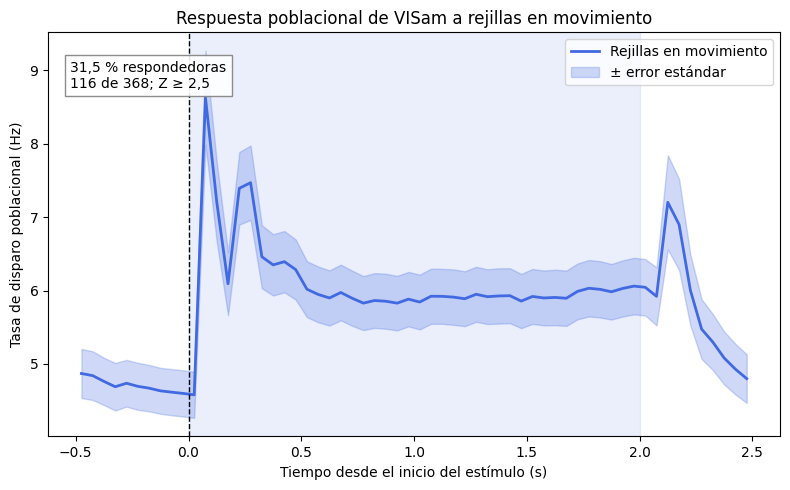

In [30]:
ensayos_rejillas_validas_global = idx_rejillas[
    columnas_rejillas_validas
]

t_pop, promedio_rejillas, sem_rejillas, tasas_pop_rejillas = (
    psth_poblacional(
        ensayos_rejillas_validas_global
    )
)

plt.figure(figsize=(8, 5))

plt.plot(
    t_pop,
    promedio_rejillas,
    color="royalblue",
    linewidth=2,
    label="Rejillas en movimiento"
)

plt.fill_between(
    t_pop,
    promedio_rejillas - sem_rejillas,
    promedio_rejillas + sem_rejillas,
    color="royalblue",
    alpha=0.25,
    label="± error estándar"
)

plt.axvspan(
    0,
    2,
    color="royalblue",
    alpha=0.10
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Tiempo desde el inicio del estímulo (s)")
plt.ylabel("Tasa de disparo poblacional (Hz)")
plt.title("Respuesta poblacional de VISam a rejillas en movimiento")

plt.text(
    0.03,
    0.93,
    "31,5 % respondedoras\n116 de 368; Z ≥ 2,5",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.legend()
plt.tight_layout()
# Guardar

plt.savefig(
    "panel_2A.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

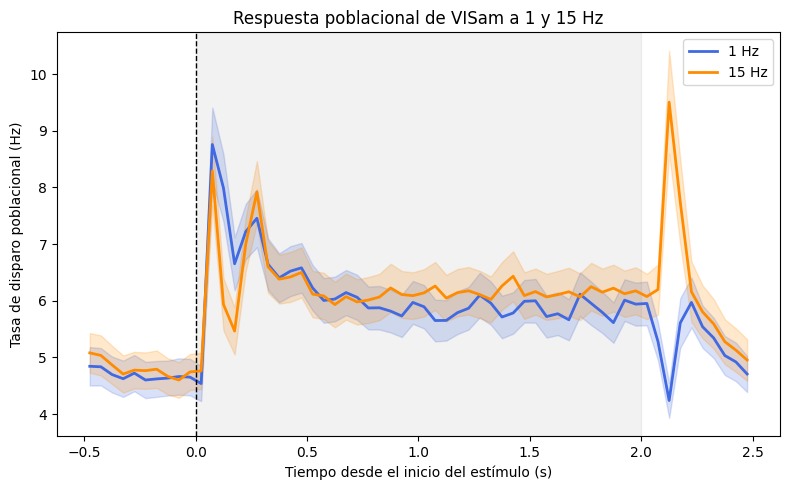

In [31]:
ensayos_1hz_global = idx_rejillas[columnas_1hz]
ensayos_15hz_global = idx_rejillas[columnas_15hz]

t_pop, promedio_1hz, sem_1hz, tasas_pop_1hz = (
    psth_poblacional(ensayos_1hz_global)
)

_, promedio_15hz, sem_15hz, tasas_pop_15hz = (
    psth_poblacional(ensayos_15hz_global)
)

plt.figure(figsize=(8, 5))

plt.plot(
    t_pop,
    promedio_1hz,
    color="royalblue",
    linewidth=2,
    label="1 Hz"
)

plt.fill_between(
    t_pop,
    promedio_1hz - sem_1hz,
    promedio_1hz + sem_1hz,
    color="royalblue",
    alpha=0.20
)

plt.plot(
    t_pop,
    promedio_15hz,
    color="darkorange",
    linewidth=2,
    label="15 Hz"
)

plt.fill_between(
    t_pop,
    promedio_15hz - sem_15hz,
    promedio_15hz + sem_15hz,
    color="darkorange",
    alpha=0.20
)

plt.axvspan(
    0,
    2,
    color="gray",
    alpha=0.10
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Tiempo desde el inicio del estímulo (s)")
plt.ylabel("Tasa de disparo poblacional (Hz)")
plt.title("Respuesta poblacional de VISam a 1 y 15 Hz")
plt.legend()
plt.tight_layout()
plt.show()

#**FIGURA 2**
#**PANEL B**
RESPUESTA POBLACIONAL DE VISam POR CLASE DE ESTIMULO

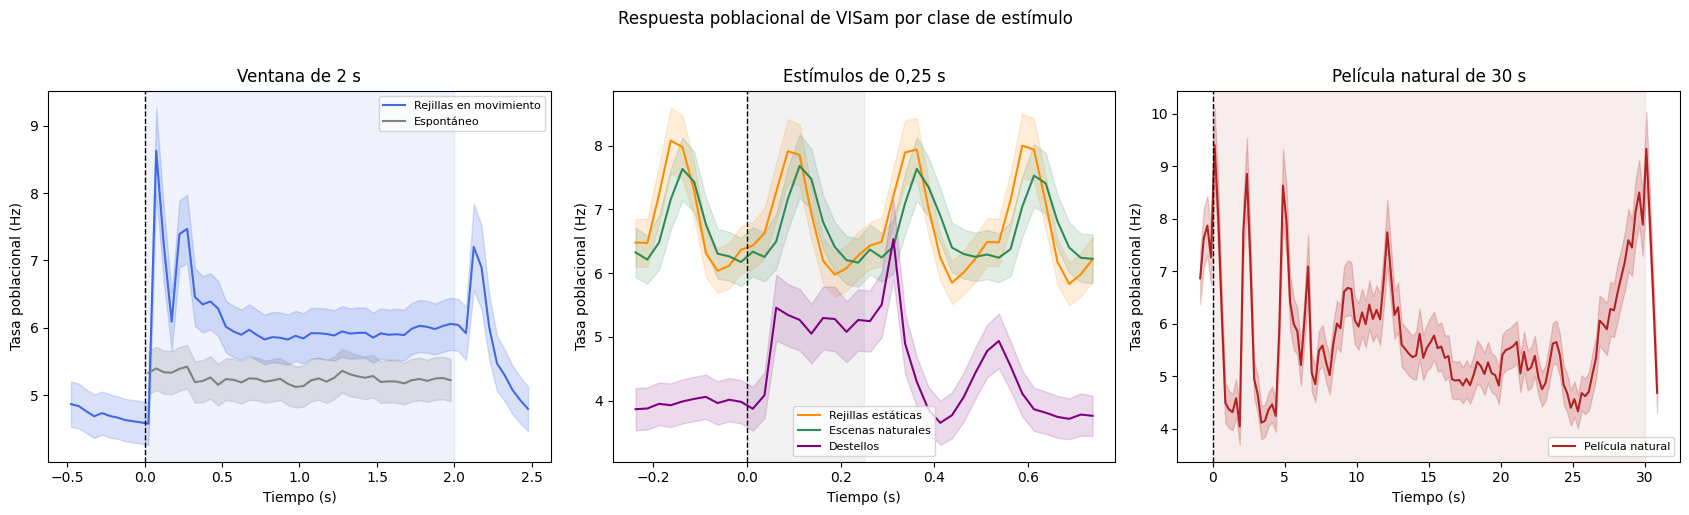

In [32]:
# Índices globales por clase
idx_static = np.where(
    d["e_clase"] == "static_gratings"
)[0]

idx_scenes = np.where(
    d["e_clase"] == "natural_scenes"
)[0]

idx_flashes = np.where(
    d["e_clase"] == "flashes"
)[0]

idx_movie = np.where(
    d["e_clase"] == "natural_movie_one"
)[0]

# Grupo 1: estímulos o periodos de 2 segundos


t_2s, psth_drifting, sem_drifting, _ = psth_poblacional(
    ensayos_rejillas_validas_global,
    inicio=-0.5,
    final=2.5,
    ancho_bin=0.05
)

_, psth_spontaneous, sem_spontaneous, _ = psth_poblacional(
    idx_espontaneo,
    inicio=-0.5,
    final=2.5,
    ancho_bin=0.05
)

# Spontaneous solo tiene datos válidos entre 0 y 2 segundos
psth_spontaneous_plot = psth_spontaneous.copy()
sem_spontaneous_plot = sem_spontaneous.copy()

fuera_del_ensayo = (t_2s < 0) | (t_2s >= 2)

psth_spontaneous_plot[fuera_del_ensayo] = np.nan
sem_spontaneous_plot[fuera_del_ensayo] = np.nan

# Grupo 2: estímulos de 0,25 segundos


t_cortos, psth_static, sem_static, _ = psth_poblacional(
    idx_static,
    inicio=-0.25,
    final=0.75,
    ancho_bin=0.025
)

_, psth_scenes, sem_scenes, _ = psth_poblacional(
    idx_scenes,
    inicio=-0.25,
    final=0.75,
    ancho_bin=0.025
)

_, psth_flashes, sem_flashes, _ = psth_poblacional(
    idx_flashes,
    inicio=-0.25,
    final=0.75,
    ancho_bin=0.025
)


# Grupo 3: película de 30 segundos


t_movie, psth_movie, sem_movie, _ = psth_poblacional(
    idx_movie,
    inicio=-1,
    final=31,
    ancho_bin=0.25
)


# Crear las tres gráficas


fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

# ---------- Estímulos de 2 s ----------
ax = axes[0]

ax.plot(
    t_2s,
    psth_drifting,
    color="royalblue",
    label="Rejillas en movimiento"
)

ax.fill_between(
    t_2s,
    psth_drifting - sem_drifting,
    psth_drifting + sem_drifting,
    color="royalblue",
    alpha=0.20
)

ax.plot(
    t_2s,
    psth_spontaneous_plot,
    color="gray",
    label="Espontáneo"
)

ax.fill_between(
    t_2s,
    psth_spontaneous_plot - sem_spontaneous_plot,
    psth_spontaneous_plot + sem_spontaneous_plot,
    color="gray",
    alpha=0.20
)

ax.axvspan(
    0,
    2,
    color="royalblue",
    alpha=0.08
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title("Ventana de 2 s")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Tasa poblacional (Hz)")
ax.legend(fontsize=8)

# ---------- Estímulos de 0,25 s ----------
ax = axes[1]

condiciones_cortas = [
    ("Rejillas estáticas", psth_static, sem_static, "darkorange"),
    ("Escenas naturales", psth_scenes, sem_scenes, "seagreen"),
    ("Destellos", psth_flashes, sem_flashes, "purple")
]

for nombre, promedio, sem, color in condiciones_cortas:

    ax.plot(
        t_cortos,
        promedio,
        color=color,
        label=nombre
    )

    ax.fill_between(
        t_cortos,
        promedio - sem,
        promedio + sem,
        color=color,
        alpha=0.15
    )

ax.axvspan(
    0,
    0.25,
    color="gray",
    alpha=0.10
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title("Estímulos de 0,25 s")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Tasa poblacional (Hz)")
ax.legend(fontsize=8)

# ---------- Película de 30 s ----------
ax = axes[2]

ax.plot(
    t_movie,
    psth_movie,
    color="firebrick",
    label="Película natural"
)

ax.fill_between(
    t_movie,
    psth_movie - sem_movie,
    psth_movie + sem_movie,
    color="firebrick",
    alpha=0.20
)

ax.axvspan(
    0,
    30,
    color="firebrick",
    alpha=0.08
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title("Película natural de 30 s")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Tasa poblacional (Hz)")
ax.legend(fontsize=8)

# ---------- Título general ----------
fig.suptitle(
    "Respuesta poblacional de VISam por clase de estímulo",
    y=1.02
)

plt.tight_layout()
# Guardar

plt.savefig(
    "panel_2B.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

#**FIGURA 2**
#**PANEL C**
RESPUESTA DE LAS NEURONAS DE VISam POR CLASE DE ESTIMULO

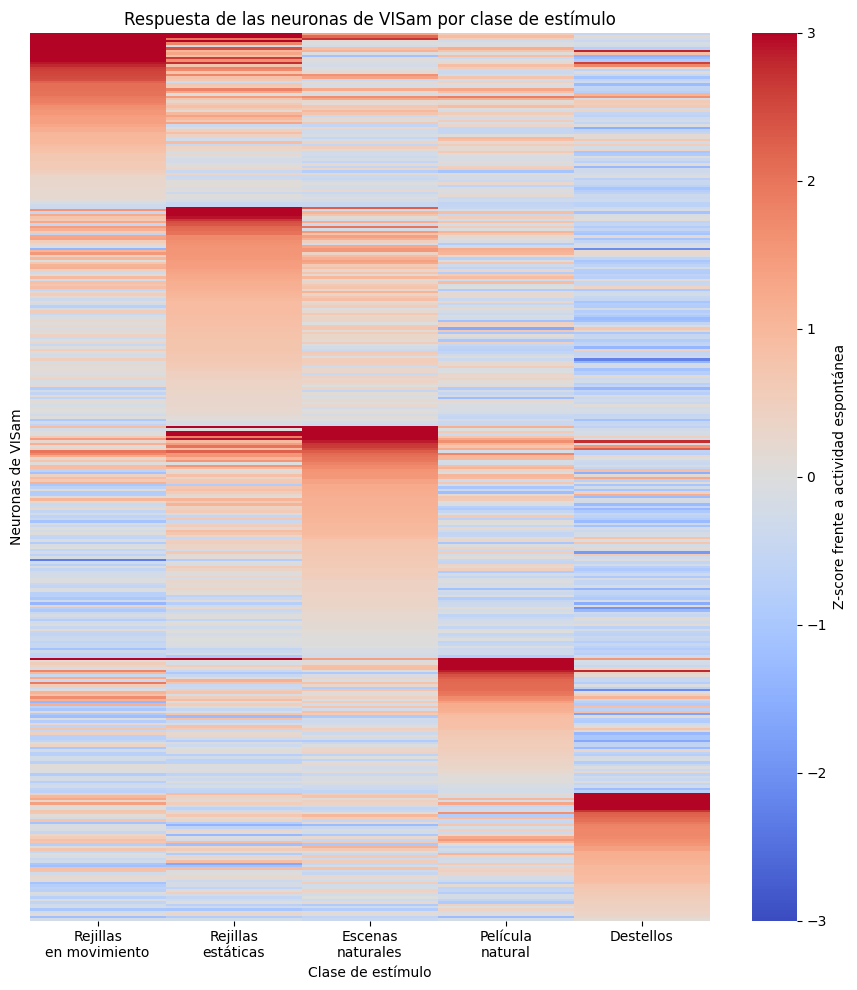

Forma de la matriz de Z-scores: (368, 5)

Z-score mediano por clase:
Rejillas en movimiento: 0.07
Rejillas estáticas: 0.31
Escenas naturales: 0.24
Película natural: 0.04
Destellos: -0.30


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# PANEL 2C: mapa de calor por clase de estímulo


n_neuronas = len(d["u_id"])
n_ensayos = len(d["e_clase"])

clases_estimulo = [
    "drifting_gratings",
    "static_gratings",
    "natural_scenes",
    "natural_movie_one",
    "flashes"
]

nombres_clases = [
    "Rejillas\nen movimiento",
    "Rejillas\nestáticas",
    "Escenas\nnaturales",
    "Película\nnatural",
    "Destellos"
]


# 1. Contar las espigas durante cada estímulo


unidad_spike = d["s_unidad"].astype(int)
ensayo_spike = d["s_ensayo"].astype(int)
tiempo_spike = d["s_t"]

duracion_spike = d["e_dur"][ensayo_spike]

# Solo espigas desde el inicio hasta el final de cada estímulo
spikes_durante_estimulo = (
    (tiempo_spike >= 0)
    & (tiempo_spike < duracion_spike)
    & np.isfinite(duracion_spike)
    & (duracion_spike > 0)
)

conteos = np.zeros(
    (n_neuronas, n_ensayos),
    dtype=np.int32
)

np.add.at(
    conteos,
    (
        unidad_spike[spikes_durante_estimulo],
        ensayo_spike[spikes_durante_estimulo]
    ),
    1
)

# Tasa de disparo de cada neurona en cada ensayo
tasas_ensayos = np.full(
    (n_neuronas, n_ensayos),
    np.nan
)

duraciones_validas = (
    np.isfinite(d["e_dur"])
    & (d["e_dur"] > 0)
)

tasas_ensayos[:, duraciones_validas] = (
    conteos[:, duraciones_validas]
    / d["e_dur"][duraciones_validas][None, :]
)

# 2. Calcular la distribución basal de cada neurona


media_basal_clases = np.full(n_neuronas, np.nan)
sd_basal_clases = np.full(n_neuronas, np.nan)

for neurona in range(n_neuronas):

    raton = d["u_raton"][neurona]

    ensayos_basales_neurona = np.where(
        (d["e_clase"] == "spontaneous")
        & (d["e_raton"] == raton)
    )[0]

    tasas_basales_neurona = tasas_ensayos[
        neurona,
        ensayos_basales_neurona
    ]

    media_basal_clases[neurona] = np.nanmean(
        tasas_basales_neurona
    )

    sd_basal_clases[neurona] = np.nanstd(
        tasas_basales_neurona,
        ddof=1
    )


# 3. Calcular un Z-score por neurona y clase


z_por_clase = np.full(
    (n_neuronas, len(clases_estimulo)),
    np.nan
)

for neurona in range(n_neuronas):

    raton = d["u_raton"][neurona]

    for columna, clase in enumerate(clases_estimulo):

        mascara = (
            (d["e_clase"] == clase)
            & (d["e_raton"] == raton)
        )

        # Excluir los barridos en blanco de drifting gratings
        if clase == "drifting_gratings":

            mascara = (
                mascara
                & np.isfinite(d["e_orientacion"])
                & np.isfinite(d["e_frec_temporal"])
                & np.isfinite(d["e_frec_espacial"])
            )

        ensayos_clase = np.where(mascara)[0]

        tasa_media_clase = np.nanmean(
            tasas_ensayos[
                neurona,
                ensayos_clase
            ]
        )

        if (
            np.isfinite(sd_basal_clases[neurona])
            and sd_basal_clases[neurona] > 0
        ):

            z_por_clase[neurona, columna] = (
                tasa_media_clase
                - media_basal_clases[neurona]
            ) / sd_basal_clases[neurona]


# 4. Ordenar las neuronas por su clase preferida


z_para_ordenar = np.nan_to_num(
    z_por_clase,
    nan=-np.inf
)

clase_preferida = np.argmax(
    z_para_ordenar,
    axis=1
)

respuesta_maxima = np.max(
    z_para_ordenar,
    axis=1
)

orden_neuronas = np.lexsort(
    (-respuesta_maxima, clase_preferida)
)


# 5. Dibujar el mapa de calor

plt.figure(figsize=(9, 10))

ax = sns.heatmap(
    z_por_clase[orden_neuronas],
    cmap="coolwarm",
    center=0,
    vmin=-3,
    vmax=3,
    xticklabels=nombres_clases,
    yticklabels=False,
    cbar_kws={
        "label": "Z-score frente a actividad espontánea"
    }
)

ax.set_xlabel("Clase de estímulo")
ax.set_ylabel("Neuronas de VISam")
ax.set_title(
    "Respuesta de las neuronas de VISam por clase de estímulo"
)

plt.tight_layout()
# Guardar

plt.savefig(
    "panel_2C.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


# 6. Comprobaciones


print(
    "Forma de la matriz de Z-scores:",
    z_por_clase.shape
)

print("\nZ-score mediano por clase:")

for nombre, columna in zip(
    nombres_clases,
    range(len(clases_estimulo))
):
    nombre_impreso = nombre.replace("\n", " ")

    print(
        f"{nombre_impreso}: "
        f"{np.nanmedian(z_por_clase[:, columna]):.2f}"
    )

#**FIGURA 2**
#**PANEL D**
RESPUESTA DE NEURONAS A LOS DOS ESTIMULOS ASIGNADOS

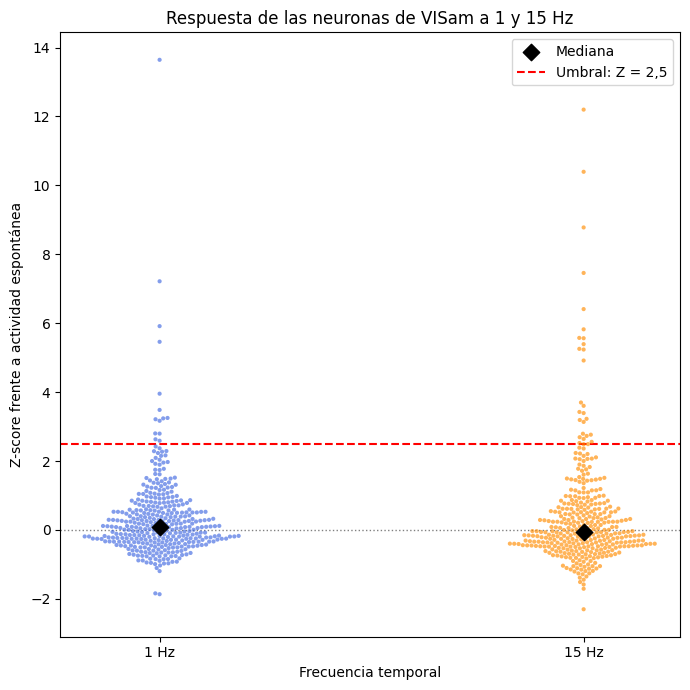

Mediana 1 Hz: 0.09
Mediana 15 Hz: -0.06
Neuronas incluidas: 368 para 1 Hz y 368 para 15 Hz


In [34]:
#panel 2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# La matriz tiene las columnas:
# 1 Hz, 2 Hz, 4 Hz, 8 Hz y 15 Hz

z_1hz = z_por_frecuencia[:, 0]
z_15hz = z_por_frecuencia[:, 4]

# Tabla para graficar
datos_enjambre = pd.DataFrame({
    "Frecuencia": (
        ["1 Hz"] * len(z_1hz)
        + ["15 Hz"] * len(z_15hz)
    ),
    "Z-score": np.concatenate([
        z_1hz,
        z_15hz
    ])
})

# Eliminar valores no finitos
datos_enjambre = datos_enjambre[
    np.isfinite(datos_enjambre["Z-score"])
]


# Panel 2D



plt.figure(figsize=(7, 7))

# Un punto por neurona
sns.swarmplot(
    data=datos_enjambre,
    x="Frecuencia",
    y="Z-score",
    hue="Frecuencia",
    palette={
        "1 Hz": "royalblue",
        "15 Hz": "darkorange"
    },
    size=3,
    alpha=0.65,
    legend=False
)

# Mediana de cada condición
medianas = [
    np.nanmedian(z_1hz),
    np.nanmedian(z_15hz)
]

plt.scatter(
    [0, 1],
    medianas,
    color="black",
    marker="D",
    s=70,
    label="Mediana",
    zorder=5
)

# Umbral para clasificar una neurona como respondedora
plt.axhline(
    2.5,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Umbral: Z = 2,5"
)

plt.axhline(
    0,
    color="gray",
    linestyle=":",
    linewidth=1
)

plt.xlabel("Frecuencia temporal")
plt.ylabel("Z-score frente a actividad espontánea")
plt.title("Respuesta de las neuronas de VISam a 1 y 15 Hz")

plt.legend()
plt.tight_layout()
# guardar

plt.savefig(
    "panel_2D.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

print(
    f"Mediana 1 Hz: {np.nanmedian(z_1hz):.2f}"
)

print(
    f"Mediana 15 Hz: {np.nanmedian(z_15hz):.2f}"
)

print(
    f"Neuronas incluidas: "
    f"{np.isfinite(z_1hz).sum()} para 1 Hz y "
    f"{np.isfinite(z_15hz).sum()} para 15 Hz"
)

#**FIGURA 2**
#**PANEL E**
PUNTOS CONECTADOS CON LA FRACCION DE NEURONAS

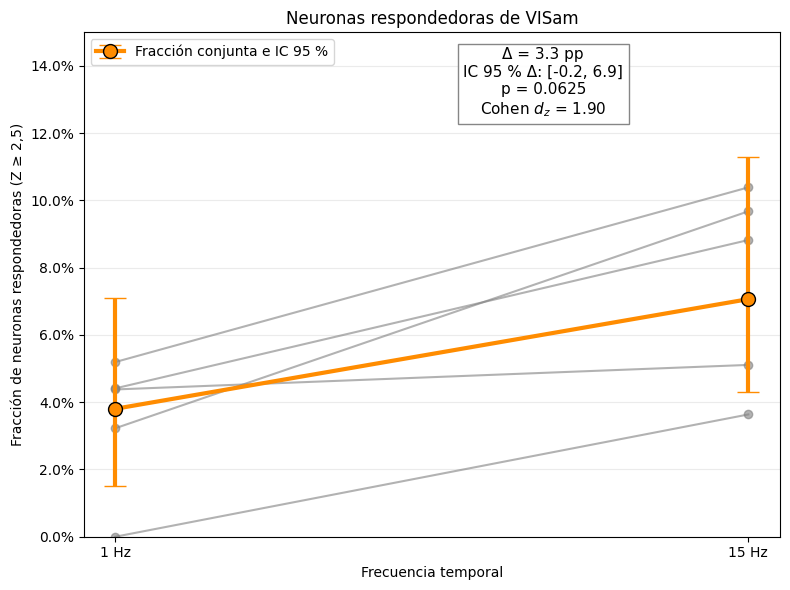

Fracciones por ratón:

Ratón 715093703: n = 31, 1 Hz = 3.2 %, 15 Hz = 9.7 %
Ratón 750749662: n = 68, 1 Hz = 4.4 %, 15 Hz = 8.8 %
Ratón 756029989: n = 77, 1 Hz = 5.2 %, 15 Hz = 10.4 %
Ratón 760345702: n = 55, 1 Hz = 0.0 %, 15 Hz = 3.6 %
Ratón 798911424: n = 137, 1 Hz = 4.4 %, 15 Hz = 5.1 %

Resultados conjuntos:
1 Hz: 3.8 %
15 Hz: 7.1 %
Diferencia: 3.3 pp
p de permutación: 0.0625
Cohen dz: 1.90


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# ============================================================
# PANEL 2E: respuesta por ratón a 1 Hz y 15 Hz
# ============================================================

umbral = 2.5

# Z-scores de las dos condiciones
z_1hz = z_por_frecuencia[:, 0]
z_15hz = z_por_frecuencia[:, 4]

# Clasificar cada neurona
respondedoras_1hz = z_1hz >= umbral
respondedoras_15hz = z_15hz >= umbral

# Ratones incluidos
ratones = np.unique(
    d["u_raton"]
)

fracciones_1hz_raton = []
fracciones_15hz_raton = []
n_neuronas_raton = []

# ============================================================
# Fracción respondedora de cada ratón
# ============================================================

for raton in ratones:

    mascara_raton = (
        d["u_raton"] == raton
    )

    n_raton = np.sum(
        mascara_raton
    )

    fraccion_1 = np.mean(
        respondedoras_1hz[
            mascara_raton
        ]
    )

    fraccion_15 = np.mean(
        respondedoras_15hz[
            mascara_raton
        ]
    )

    n_neuronas_raton.append(
        n_raton
    )

    fracciones_1hz_raton.append(
        fraccion_1
    )

    fracciones_15hz_raton.append(
        fraccion_15
    )

fracciones_1hz_raton = np.array(
    fracciones_1hz_raton
)

fracciones_15hz_raton = np.array(
    fracciones_15hz_raton
)

# ============================================================
# Fracciones conjuntas
# ============================================================

fraccion_conjunta_1hz = np.mean(
    respondedoras_1hz
)

fraccion_conjunta_15hz = np.mean(
    respondedoras_15hz
)

# Intervalos obtenidos previamente con el bootstrap jerárquico
ic_1hz = np.array([
    0.015,
    0.071
])

ic_15hz = np.array([
    0.043,
    0.113
])

# Diferencia e intervalo jerárquico
diferencia_conjunta = (
    fraccion_conjunta_15hz
    - fraccion_conjunta_1hz
)

ic_diferencia = np.array([
    -0.002,
    0.069
])

# ============================================================
# Prueba exacta de permutación por ratón
# ============================================================

diferencias_raton = (
    fracciones_15hz_raton
    - fracciones_1hz_raton
)

diferencia_observada = np.mean(
    diferencias_raton
)

medias_permutadas = []

# Todas las 2^5 combinaciones de signos
for signos in product(
    [-1, 1],
    repeat=len(ratones)
):

    signos = np.array(
        signos
    )

    media_permutada = np.mean(
        diferencias_raton
        * signos
    )

    medias_permutadas.append(
        media_permutada
    )

medias_permutadas = np.array(
    medias_permutadas
)

p_permutacion = np.mean(
    np.abs(medias_permutadas)
    >= np.abs(diferencia_observada) - 1e-12
)

# ============================================================
# Cohen dz sobre las diferencias entre ratones
# ============================================================

cohen_dz = (
    np.mean(diferencias_raton)
    / np.std(
        diferencias_raton,
        ddof=1
    )
)

# ============================================================
# Construir la gráfica
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)

x = np.array([
    0,
    1
])

# Una línea gris por ratón
for indice, raton in enumerate(ratones):

    valores_raton = [
        fracciones_1hz_raton[indice],
        fracciones_15hz_raton[indice]
    ]

    ax.plot(
        x,
        valores_raton,
        color="gray",
        alpha=0.60,
        linewidth=1.5,
        marker="o",
        markersize=6
    )

# Errores asimétricos de las fracciones conjuntas
error_inferior = [
    fraccion_conjunta_1hz - ic_1hz[0],
    fraccion_conjunta_15hz - ic_15hz[0]
]

error_superior = [
    ic_1hz[1] - fraccion_conjunta_1hz,
    ic_15hz[1] - fraccion_conjunta_15hz
]

errores = np.array([
    error_inferior,
    error_superior
])

# Fracción conjunta e IC 95 %
ax.errorbar(
    x,
    [
        fraccion_conjunta_1hz,
        fraccion_conjunta_15hz
    ],
    yerr=errores,
    color="darkorange",
    marker="o",
    markeredgecolor="black",
    markerfacecolor="darkorange",
    markersize=10,
    linewidth=3,
    capsize=8,
    label="Fracción conjunta e IC 95 %"
)

# Información estadística
texto_estadistico = (
    f"Δ = {diferencia_conjunta * 100:.1f} pp\n"
    f"IC 95 % Δ: "
    f"[{ic_diferencia[0] * 100:.1f}, "
    f"{ic_diferencia[1] * 100:.1f}]\n"
    f"p = {p_permutacion:.4f}\n"
    f"Cohen $d_z$ = {cohen_dz:.2f}"
)

ax.text(
    0.66,
    0.97,
    texto_estadistico,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
    bbox={
        "facecolor": "white",
        "edgecolor": "gray",
        "alpha": 0.95
    }
)

# Formato
ax.set_xticks(
    [0, 1]
)

ax.set_xticklabels([
    "1 Hz",
    "15 Hz"
])

ax.set_xlabel(
    "Frecuencia temporal"
)

ax.set_ylabel(
    "Fracción de neuronas respondedoras (Z ≥ 2,5)"
)

ax.set_title(
    "Neuronas respondedoras de VISam"
)

ax.set_ylim(
    0,
    0.15
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda valor, posicion:
        f"{valor * 100:.1f}%"
    )
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "panel_2E.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# ============================================================
# Imprimir valores por ratón
# ============================================================

print("Fracciones por ratón:\n")

for indice, raton in enumerate(ratones):

    print(
        f"Ratón {raton}: "
        f"n = {n_neuronas_raton[indice]}, "
        f"1 Hz = "
        f"{fracciones_1hz_raton[indice] * 100:.1f} %, "
        f"15 Hz = "
        f"{fracciones_15hz_raton[indice] * 100:.1f} %"
    )

print("\nResultados conjuntos:")

print(
    f"1 Hz: "
    f"{fraccion_conjunta_1hz * 100:.1f} %"
)

print(
    f"15 Hz: "
    f"{fraccion_conjunta_15hz * 100:.1f} %"
)

print(
    f"Diferencia: "
    f"{diferencia_conjunta * 100:.1f} pp"
)

print(
    f"p de permutación: "
    f"{p_permutacion:.4f}"
)

print(
    f"Cohen dz: "
    f"{cohen_dz:.2f}"
)

#FIGURA FINAL
#FIGURA 2

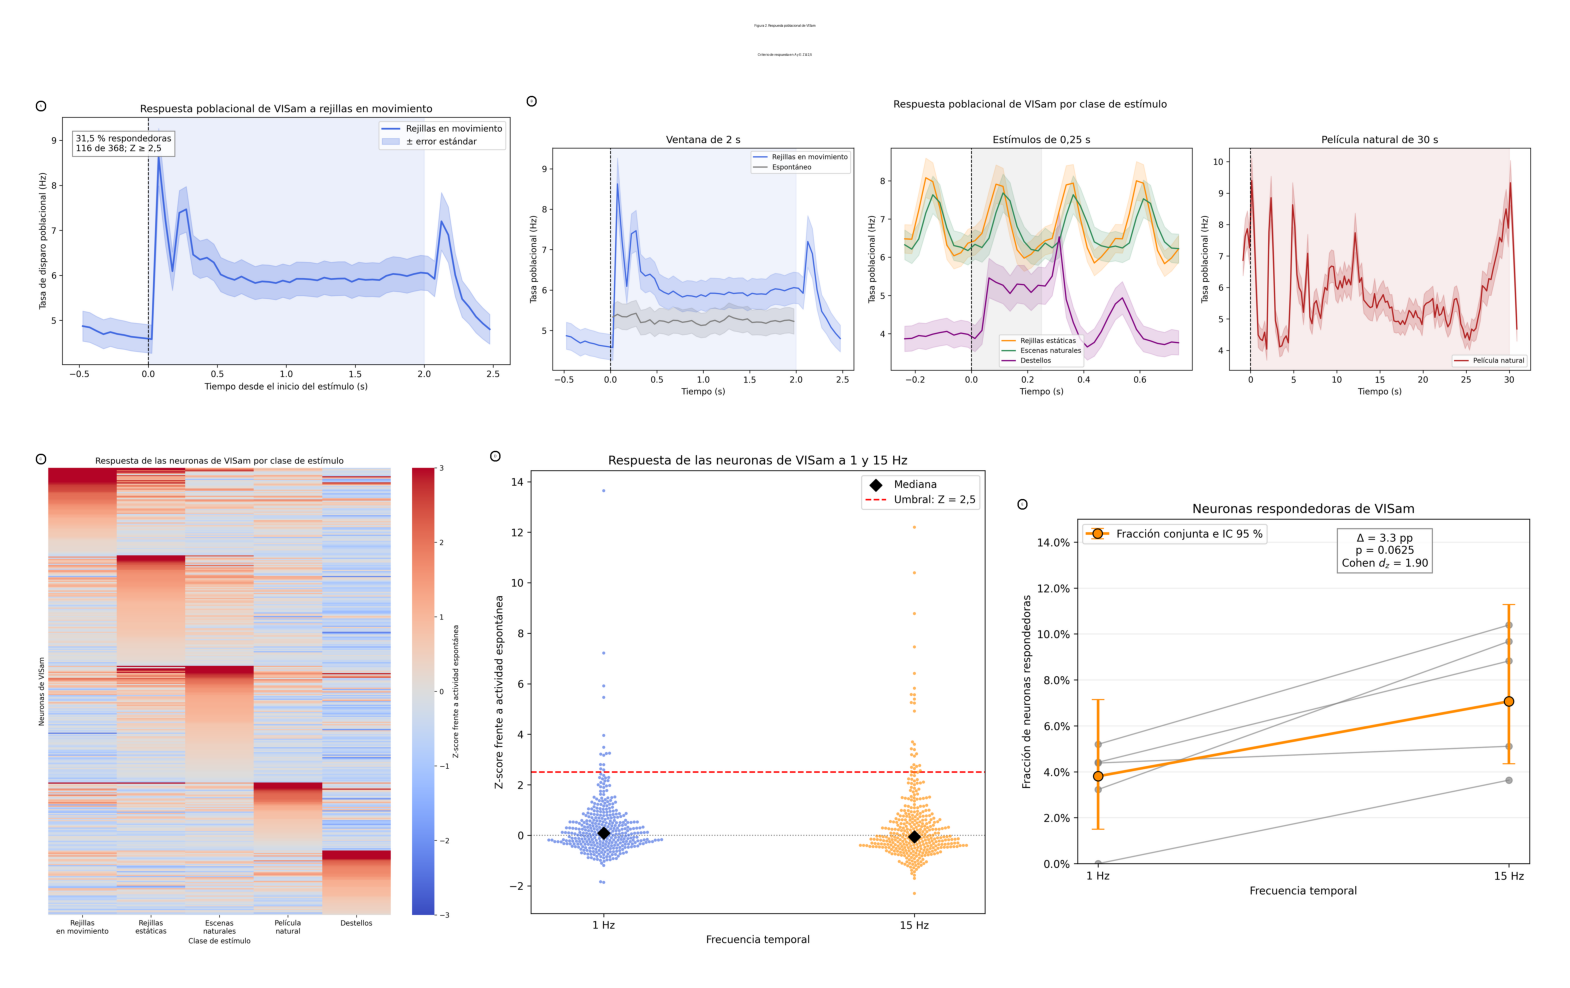

Figura guardada como: Figura_2_VISam_completa.png


In [35]:
from PIL import Image, ImageChops, ImageDraw, ImageFont
import matplotlib.pyplot as plt


# Cargar los cinco paneles


archivos = {
    "A": "panel_2A.png",
    "B": "panel_2B.png",
    "C": "panel_2C.png",
    "D": "panel_2D.png",
    "E": "panel_2E.png"
}

paneles = {
    letra: Image.open(archivo).convert("RGB")
    for letra, archivo in archivos.items()
}

# Función para quitar bordes blancos excesivos


def recortar_blanco(imagen, margen=15):

    fondo = Image.new(
        "RGB",
        imagen.size,
        "white"
    )

    diferencia = ImageChops.difference(
        imagen,
        fondo
    ).convert("L")

    diferencia = diferencia.point(
        lambda valor: 255 if valor > 12 else 0
    )

    caja = diferencia.getbbox()

    if caja is None:
        return imagen

    izquierda = max(0, caja[0] - margen)
    arriba = max(0, caja[1] - margen)
    derecha = min(imagen.width, caja[2] + margen)
    abajo = min(imagen.height, caja[3] + margen)

    return imagen.crop(
        (izquierda, arriba, derecha, abajo)
    )

paneles = {
    letra: recortar_blanco(imagen)
    for letra, imagen in paneles.items()
}


# Crear el lienzo de la Figura 2


ancho_total = 4800
alto_total = 3000

figura_2 = Image.new(
    "RGB",
    (ancho_total, alto_total),
    "white"
)

dibujo = ImageDraw.Draw(figura_2)

# Fuentes
try:

    fuente_titulo = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        76
    )

    fuente_subtitulo = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        34
    )

    fuente_letra = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        82
    )

except:

    fuente_titulo = ImageFont.load_default()
    fuente_subtitulo = ImageFont.load_default()
    fuente_letra = ImageFont.load_default()


# Título general


titulo = "Figura 2. Respuesta poblacional de VISam"

caja_titulo = dibujo.textbbox(
    (0, 0),
    titulo,
    font=fuente_titulo
)

ancho_titulo = (
    caja_titulo[2]
    - caja_titulo[0]
)

dibujo.text(
    (
        (ancho_total - ancho_titulo) / 2,
        45
    ),
    titulo,
    fill="black",
    font=fuente_titulo
)

subtitulo = "Criterio de respuesta en A y E: Z ≥ 2,5"

caja_subtitulo = dibujo.textbbox(
    (0, 0),
    subtitulo,
    font=fuente_subtitulo
)

ancho_subtitulo = (
    caja_subtitulo[2]
    - caja_subtitulo[0]
)

dibujo.text(
    (
        (ancho_total - ancho_subtitulo) / 2,
        135
    ),
    subtitulo,
    fill="black",
    font=fuente_subtitulo
)


# Posición de cada panel
# x, y, ancho máximo, alto máximo


posiciones = {
    "A": (80, 180, 1480, 1120),
    "B": (1600, 180, 3120, 1120),
    "C": (80, 1370, 1320, 1540),
    "D": (1440, 1370, 1640, 1540),
    "E": (3120, 1370, 1600, 1540)
}


# Colocar cada panel


for letra, imagen in paneles.items():

    x, y, ancho_maximo, alto_maximo = posiciones[letra]

    # Redimensionar sin deformar
    imagen.thumbnail(
        (ancho_maximo, alto_maximo),
        Image.Resampling.LANCZOS
    )

    # Centrar dentro de su espacio
    posicion_x = (
        x
        + (ancho_maximo - imagen.width) // 2
    )

    posicion_y = (
        y
        + (alto_maximo - imagen.height) // 2
    )

    figura_2.paste(
        imagen,
        (posicion_x, posicion_y)
    )

    # Letra del panel
    letra_x = posicion_x + 12
    letra_y = posicion_y + 8

    caja_letra = dibujo.textbbox(
        (letra_x, letra_y),
        letra,
        font=fuente_letra
    )

    margen_letra = 12

    dibujo.rounded_rectangle(
        (
            caja_letra[0] - margen_letra,
            caja_letra[1] - margen_letra,
            caja_letra[2] + margen_letra,
            caja_letra[3] + margen_letra
        ),
        radius=14,
        fill="white",
        outline="black",
        width=4
    )

    dibujo.text(
        (letra_x, letra_y),
        letra,
        fill="black",
        font=fuente_letra
    )


# Guardar y mostrar


figura_2.save(
    "Figura_2_VISam_completa.png",
    dpi=(300, 300)
)

plt.figure(figsize=(20, 13))
plt.imshow(figura_2)
plt.axis("off")
plt.show()

print(
    "Figura guardada como: "
    "Figura_2_VISam_completa.png"
)

In [37]:
print("Matrices disponibles:\n")

for nombre, valor in list(globals().items()):

    if isinstance(valor, np.ndarray):

        if valor.shape in [(368, 5), (368,)]:

            print(
                nombre,
                "→",
                valor.shape
            )

Matrices disponibles:

n_validos → (368,)
suma_tasas → (368,)
condicion_preferida → (368,)
tasa_preferida → (368,)
media_basal → (368,)
desviacion_basal → (368,)
z_score → (368,)
respondedoras → (368,)
neuronas_raton → (368,)
media_1hz → (368,)
media_15hz → (368,)
z_1hz → (368,)
z_15hz → (368,)
media_por_frecuencia → (368, 5)
z_por_frecuencia → (368, 5)
indice_frecuencia_preferida → (368,)
frecuencia_preferida → (368,)
respuesta_maxima → (368,)
orden_neuronas → (368,)
respondedoras_1hz → (368,)
respondedoras_15hz → (368,)
media_basal_b → (368,)
sd_basal_b → (368,)
z1_b → (368,)
z15_b → (368,)
media_basal_clases → (368,)
sd_basal_clases → (368,)
z_por_clase → (368, 5)
z_para_ordenar → (368, 5)
clase_preferida → (368,)


In [38]:
variables_encontradas = []

for nombre, valor in list(globals().items()):

    if isinstance(valor, np.ndarray):

        if valor.shape == (368, 5):

            variables_encontradas.append(nombre)

print(
    "Matrices de forma (368, 5):",
    variables_encontradas
)

Matrices de forma (368, 5): ['media_por_frecuencia', 'z_por_frecuencia', 'z_por_clase', 'z_para_ordenar']


#**BOOTSTRAP JERARQUICO**


In [39]:
import numpy as np
from scipy import stats


# 1. Reconstruir las tasas de disparo entre 0 y 2 segundos


n_neuronas = len(d["u_id"])
n_ensayos = len(d["e_clase"])

conteos_2s = np.zeros(
    (n_neuronas, n_ensayos),
    dtype=np.int32
)

spikes_en_ventana = (
    (d["s_t"] >= 0)
    & (d["s_t"] < 2)
)

np.add.at(
    conteos_2s,
    (
        d["s_unidad"][spikes_en_ventana].astype(int),
        d["s_ensayo"][spikes_en_ventana].astype(int)
    ),
    1
)

# Tasa en Hz: número de espigas dividido por 2 segundos
tasas_2s = conteos_2s / 2


# 2. Calcular la media y desviación basal de cada neurona


media_basal = np.full(
    n_neuronas,
    np.nan
)

sd_basal = np.full(
    n_neuronas,
    np.nan
)

for neurona in range(n_neuronas):

    raton = d["u_raton"][neurona]

    ensayos_basales = np.where(
        (d["e_clase"] == "spontaneous")
        & (d["e_raton"] == raton)
    )[0]

    tasas_basales = tasas_2s[
        neurona,
        ensayos_basales
    ]

    media_basal[neurona] = np.mean(
        tasas_basales
    )

    sd_basal[neurona] = np.std(
        tasas_basales,
        ddof=1
    )


# 3. Z-score para cada frecuencia temporal

frecuencias = np.array([
    1,
    2,
    4,
    8,
    15
])

tasas_por_frecuencia = np.full(
    (n_neuronas, len(frecuencias)),
    np.nan
)

z_por_frecuencia = np.full(
    (n_neuronas, len(frecuencias)),
    np.nan
)

ensayos_validos_por_frecuencia = {}

for columna, frecuencia in enumerate(frecuencias):

    ensayos_frecuencia_globales = np.where(
        (d["e_clase"] == "drifting_gratings")
        & np.isfinite(d["e_frec_temporal"])
        & (d["e_frec_temporal"] == frecuencia)
    )[0]

    ensayos_validos_por_frecuencia[frecuencia] = (
        len(ensayos_frecuencia_globales)
    )

    for neurona in range(n_neuronas):

        raton = d["u_raton"][neurona]

        ensayos_neurona = ensayos_frecuencia_globales[
            d["e_raton"][
                ensayos_frecuencia_globales
            ] == raton
        ]

        tasa_media = np.mean(
            tasas_2s[
                neurona,
                ensayos_neurona
            ]
        )

        tasas_por_frecuencia[
            neurona,
            columna
        ] = tasa_media

        if (
            np.isfinite(sd_basal[neurona])
            and sd_basal[neurona] > 0
        ):

            z_por_frecuencia[
                neurona,
                columna
            ] = (
                tasa_media
                - media_basal[neurona]
            ) / sd_basal[neurona]

# Comprobación
print(
    "Forma de la matriz de Z-scores:",
    z_por_frecuencia.shape
)

for columna, frecuencia in enumerate(frecuencias):

    print(
        f"{frecuencia} Hz: "
        f"Z mediano = "
        f"{np.nanmedian(z_por_frecuencia[:, columna]):.2f}"
    )


# 4. Clasificar las neuronas como respondedoras


z_1hz = z_por_frecuencia[:, 0]
z_15hz = z_por_frecuencia[:, 4]

neuronas_validas = (
    np.isfinite(z_1hz)
    & np.isfinite(z_15hz)
)

respondedoras_1hz = (
    z_1hz[neuronas_validas] >= 2.5
).astype(int)

respondedoras_15hz = (
    z_15hz[neuronas_validas] >= 2.5
).astype(int)

diferencia_por_neurona = (
    respondedoras_15hz
    - respondedoras_1hz
)

n_validas = len(
    diferencia_por_neurona
)


# 5. T-test ingenuo que ignora el ratón


diferencia_media = np.mean(
    diferencia_por_neurona
)

error_estandar_ingenuo = stats.sem(
    diferencia_por_neurona
)

ic_ingenuo = stats.t.interval(
    confidence=0.95,
    df=n_validas - 1,
    loc=diferencia_media,
    scale=error_estandar_ingenuo
)

t_ingenuo, p_ingenuo = stats.ttest_1samp(
    diferencia_por_neurona,
    popmean=0
)


# 6. Imprimir la comparación


print("\nANÁLISIS INGENUO: se ignora el ratón")
print("-------------------------------------")

print(
    f"Neuronas analizadas: {n_validas}"
)

print(
    f"Respondedoras a 1 Hz: "
    f"{respondedoras_1hz.sum()} de {n_validas} "
    f"({respondedoras_1hz.mean() * 100:.1f} %)"
)

print(
    f"Respondedoras a 15 Hz: "
    f"{respondedoras_15hz.sum()} de {n_validas} "
    f"({respondedoras_15hz.mean() * 100:.1f} %)"
)

print(
    f"Diferencia 15 Hz − 1 Hz: "
    f"{diferencia_media * 100:.1f} puntos porcentuales"
)

print(
    f"IC 95 % ingenuo: "
    f"[{ic_ingenuo[0] * 100:.1f}, "
    f"{ic_ingenuo[1] * 100:.1f}]"
)

print(
    f"t = {t_ingenuo:.3f}"
)

print(
    f"p = {p_ingenuo:.4f}"
)

print("\nBOOTSTRAP JERÁRQUICO")
print("--------------------")
print("Diferencia: 3.3 puntos porcentuales")
print("IC 95 % jerárquico: [-0.2, 6.9]")
print("Prueba de permutación por ratón: p = 0.0625")

Forma de la matriz de Z-scores: (368, 5)
1 Hz: Z mediano = 0.09
2 Hz: Z mediano = 0.07
4 Hz: Z mediano = 0.01
8 Hz: Z mediano = -0.02
15 Hz: Z mediano = -0.06

ANÁLISIS INGENUO: se ignora el ratón
-------------------------------------
Neuronas analizadas: 368
Respondedoras a 1 Hz: 14 de 368 (3.8 %)
Respondedoras a 15 Hz: 26 de 368 (7.1 %)
Diferencia 15 Hz − 1 Hz: 3.3 puntos porcentuales
IC 95 % ingenuo: [0.3, 6.2]
t = 2.202
p = 0.0283

BOOTSTRAP JERÁRQUICO
--------------------
Diferencia: 3.3 puntos porcentuales
IC 95 % jerárquico: [-0.2, 6.9]
Prueba de permutación por ratón: p = 0.0625


#**USO DEL MODELO DE LENGUAJE**

Usamos un modelo de lenguaje para proponer código en Python, organizar las figuras y aclarar conceptos estadísticos. Inicialmente, el modelo contó 135 combinaciones de rejillas e identificó 171 neuronas respondedoras (46.5 %), porque incluyó ensayos sin valores válidos y combinaciones inexistentes. Revisamos las variables del archivo, eliminamos los ensayos incompletos y conservamos las 40 combinaciones reales, con lo cual obtuvimos 116 de 368 neuronas respondedoras (31.5 %). También verificamos que cada neurona se comparara únicamente con los ensayos del mismo ratón y agrupamos los PSTH según la duración de cada estímulo. Todo el código y los resultados se revisaron con los controles indicados en la guía.